# Small first-shell vs second-shell AE/VAE check

This notebook compares shallow deterministic and variational autoencoder latent representations for two invariant local-neighbourhood inputs:

- `radii`: sorted central-particle-to-neighbour distances.
- `pairwise_dist`: sorted all-pairwise distances after adding the central particle at `(0, 0, 0)`. This includes the radii implicitly.

Both inputs are evaluated for the first-shell and second-shell files on the same 3-class task: `fcc` vs `hcp` vs `liquid`.


In [1]:
SKIP_AE = False
SKIP_VAE = False
SKIP_EGNN_NORMAL = False
SKIP_EGNN_QL = False
SKIP_EGNN_ANGULAR = False

In [2]:
# Imports
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


In [3]:
# Configuration
PHASES = ["fcc", "hcp", "liquid"]
LABEL_MAP = {"fcc": 0, "hcp": 1, "liquid": 2}
LABEL_NAMES = {0: "fcc", 1: "hcp", 2: "liquid"}
LABEL_COLORS = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

SHELL_FILES = {
    "first_shell": "particle_data.npz",
    "second_shell": "particle_data_second_shell.npz",
}
SHELL_ORDER = ["first_shell", "second_shell"]
SHELL_LABELS = {
    "first_shell": "First shell",
    "second_shell": "Second shell",
}

FEATURE_KINDS = ["radii", "pairwise_dist"]
FEATURE_LABELS = {
    "radii": "Distances (radii)",
    "pairwise_dist": "Pairwise distances",
}

# Keep this first pass intentionally small. Increase after the pipeline looks right.
MAX_SAMPLES_PER_PHASE = 6000
EPOCHS = 20
BATCH_SIZE = 512
LR = 1e-3
WEIGHT_DECAY = 1e-4
LATENT_DIM = 8
VAE_BETA = 1e-2
VAE_KL_WARMUP_EPOCHS = 10
SEED = 42

# Plotting: classifier scores use the full latent. This controls only the 2D display.
VIS_METHOD = "tsne"  # "tsne", "umap", "pca", or "latent" if LATENT_DIM == 2
MAX_VIS_SAMPLES_PER_PHASE = 1000
TSNE_PERPLEXITY = 30
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.12

SCATTER_S = 10
SCATTER_ALPHA = 0.55
LEGEND_MARKERSCALE = 3.5
LEGEND_FONTSIZE = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR_CANDIDATES = [
    Path("."),
    Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
]
DATA_DIR = next(
    (p for p in DATA_DIR_CANDIDATES if all((p / phase / SHELL_FILES["second_shell"]).exists() for phase in PHASES)),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find phase directories containing particle_data_second_shell.npz")

np.random.seed(SEED)
torch.manual_seed(SEED)
print("DATA_DIR:", DATA_DIR.resolve())
print("device:", DEVICE)


DATA_DIR: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
device: cuda


## 1) Load and sort shell data

First-shell files have 12 neighbours; second-shell files have 18. Distances are sorted and `vec_dist` is reordered consistently before building either input type.


In [4]:
def scalar_from_npz(arr, key, default=None):
    if key not in arr.files:
        return default
    value = np.asarray(arr[key])
    return value.item() if value.shape == () else value.tolist()


def load_particle_data(npz_path):
    arr = np.load(npz_path, allow_pickle=True)
    nn = scalar_from_npz(arr, "nn")
    descriptor_nn = scalar_from_npz(arr, "descriptor_nn", nn)
    out = {
        "dist": arr["dist"].astype(np.float32),
        "ql": arr["ql"].astype(np.float32),
        "meta": {
            "nn": nn,
            "descriptor_nn": descriptor_nn,
            "n_pick": scalar_from_npz(arr, "n_pick"),
        },
    }
    if "ql_no_average" in arr.files:
        out["ql_no_average"] = arr["ql_no_average"].astype(np.float32)
    if "picked_ids" in arr.files:
        out["picked_ids"] = arr["picked_ids"].astype(np.int32)
    if "frame_indices" in arr.files:
        out["frame_indices"] = arr["frame_indices"].astype(np.int32)

    vec = arr["vec_dist"]
    if vec.ndim == 3 and vec.shape[2] == 3:
        out["vec_dist"] = vec.astype(np.float32)
    elif vec.ndim == 2 and vec.shape[1] % 3 == 0:
        out["vec_dist"] = vec.reshape(vec.shape[0], vec.shape[1] // 3, 3).astype(np.float32)
    else:
        raise ValueError(f"Unexpected vec_dist shape in {npz_path}: {vec.shape}")
    return out


def sort_neighbour_arrays(data_by_phase):
    for data in data_by_phase.values():
        order = np.argsort(data["dist"], axis=1)
        data["dist"] = np.take_along_axis(data["dist"], order, axis=1)
        data["vec_dist"] = np.take_along_axis(data["vec_dist"], order[:, :, None], axis=1)


def load_shell(shell_name):
    filename = SHELL_FILES[shell_name]
    data_by_phase = {}
    for phase in PHASES:
        npz_path = DATA_DIR / phase / filename
        if not npz_path.exists():
            raise FileNotFoundError(npz_path)
        data_by_phase[phase] = load_particle_data(npz_path)
    sort_neighbour_arrays(data_by_phase)
    return data_by_phase


def summarize_shell(data_by_phase, shell_name):
    rows = []
    for phase, data in data_by_phase.items():
        n_neigh = data["dist"].shape[1]
        rows.append({
            "shell": shell_name,
            "phase": phase,
            "n_samples": data["dist"].shape[0],
            "n_neighbours": n_neigh,
            "radii_dim": n_neigh,
            "pairwise_dist_dim": (n_neigh + 1) * n_neigh // 2,
            "nn_metadata": data["meta"].get("nn"),
            "descriptor_nn": data["meta"].get("descriptor_nn"),
            "dist_shape": str(data["dist"].shape),
            "vec_dist_shape": str(data["vec_dist"].shape),
            "ql_shape": str(data["ql"].shape),
        })
    return pd.DataFrame(rows)



def shell_consistency_report(shell_data):
    rows = []
    first = shell_data["first_shell"]
    second = shell_data["second_shell"]
    for phase in PHASES:
        a = first[phase]
        b = second[phase]
        rows.append({
            "phase": phase,
            "same_frame_indices": np.array_equal(a.get("frame_indices"), b.get("frame_indices")),
            "same_picked_ids": np.array_equal(a.get("picked_ids"), b.get("picked_ids")),
            "same_ql_targets": np.allclose(a["ql"], b["ql"]),
            "ql_abs_mean_diff": float(np.mean(np.abs(a["ql"] - b["ql"]))),
            "first_descriptor_nn": a["meta"].get("descriptor_nn"),
            "second_descriptor_nn": b["meta"].get("descriptor_nn"),
        })
    return pd.DataFrame(rows)

shell_data = {shell_name: load_shell(shell_name) for shell_name in SHELL_ORDER}
display(pd.concat(
    [summarize_shell(shell_data[shell_name], shell_name) for shell_name in SHELL_ORDER],
    ignore_index=True,
))
display(shell_consistency_report(shell_data))

,shell,phase,n_samples,n_neighbours,radii_dim,pairwise_dist_dim,nn_metadata,descriptor_nn,dist_shape,vec_dist_shape,ql_shape
0,first_shell,fcc,180300,12,12,78,12,12,"(180300, 12)","(180300, 12, 3)","(180300, 20)"
1,first_shell,hcp,180300,12,12,78,12,12,"(180300, 12)","(180300, 12, 3)","(180300, 20)"
2,first_shell,liquid,90300,12,12,78,12,12,"(90300, 12)","(90300, 12, 3)","(90300, 20)"
3,second_shell,fcc,180300,18,18,171,18,12,"(180300, 18)","(180300, 18, 3)","(180300, 20)"
4,second_shell,hcp,180300,18,18,171,18,12,"(180300, 18)","(180300, 18, 3)","(180300, 20)"
5,second_shell,liquid,90300,18,18,171,18,12,"(90300, 18)","(90300, 18, 3)","(90300, 20)"


,phase,same_frame_indices,same_picked_ids,same_ql_targets,ql_abs_mean_diff,first_descriptor_nn,second_descriptor_nn
0,fcc,True,True,True,0.0,12,12
1,hcp,True,True,True,0.0,12,12
2,liquid,True,True,True,0.0,12,12


## 2) Feature and autoencoder helpers

`radii` uses the sorted central-particle distances directly. `pairwise_dist` now adds the central particle at `(0, 0, 0)`, computes all pairwise distances over `central + neighbours`, and sorts those distances per particle. This makes the radii part of the pairwise signature and keeps the input invariant to global rotation, translation, and neighbour ordering.

The previous one-layer `input -> 2D ReLU -> input` AE can collapse for the larger pairwise input. The model below keeps the same reconstruction objective but uses a small capacity-scaled MLP and a linear latent space. Classification is done on the full latent vector; the 2D plot is a visualization projection of that latent.


In [5]:
class ShallowAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=LATENT_DIM):
        super().__init__()
        hidden_dim = max(32, min(256, input_dim * 2))
        mid_dim = max(16, hidden_dim // 2)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


class ShallowVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=LATENT_DIM):
        super().__init__()
        hidden_dim = max(32, min(256, input_dim * 2))
        mid_dim = max(16, hidden_dim // 2)
        self.latent_dim = latent_dim

        self.encoder_backbone = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, mid_dim),
            nn.SiLU(),
        )
        self.mu_head = nn.Linear(mid_dim, latent_dim)
        self.logvar_head = nn.Linear(mid_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, mid_dim),
            nn.SiLU(),
            nn.Linear(mid_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder_backbone(x)
        mu = self.mu_head(h)
        # Bounding log-variance avoids numerical overflow in exp(logvar) early in training.
        logvar = self.logvar_head(h).clamp(min=-12.0, max=12.0)
        return mu, logvar

    def decode(self, z):
        return self.decoder(z)
    
    def reparameterize(self, mu, logvar):
        """Draw a differentiable sample from q(z|x)."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


def with_central_point(vec):
    central = np.zeros((vec.shape[0], 1, 3), dtype=vec.dtype)
    return np.concatenate([central, vec], axis=1)


def pairwise_distance_features(vec):
    points = with_central_point(vec)
    diffs = points[:, :, None, :] - points[:, None, :, :]
    dist = np.linalg.norm(diffs, axis=-1)
    upper = np.triu_indices(points.shape[1], k=1)
    pairwise = dist[:, upper[0], upper[1]]
    return np.sort(pairwise, axis=1).astype(np.float32)


def feature_array(data, feature_kind, idx):
    if feature_kind == "radii":
        return data["dist"][idx].astype(np.float32)
    if feature_kind == "pairwise_dist":
        return pairwise_distance_features(data["vec_dist"][idx])
    raise KeyError(f"Unknown feature kind: {feature_kind}")


def make_ae_data(data_by_phase, feature_kind, selected_phases=PHASES, max_samples_per_phase=MAX_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for phase in selected_phases:
        n = data_by_phase[phase]["dist"].shape[0]
        if max_samples_per_phase is not None and n > max_samples_per_phase:
            idx = rng.choice(n, size=max_samples_per_phase, replace=False)
        else:
            idx = np.arange(n)

        X = feature_array(data_by_phase[phase], feature_kind, idx)
        y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)
        Xs.append(X.astype(np.float32))
        ys.append(y)

    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)
    return X_scaled, y, scaler


def train_shallow_ae(
    X,
    y,
    latent_dim=LATENT_DIM,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
):
    torch.manual_seed(seed)
    X_train, X_val, _, _ = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(X_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(X_val)),
        batch_size=batch_size,
        shuffle=False,
    )

    model = ShallowAutoencoder(X.shape[1], latent_dim=latent_dim).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    hist = {"loss": [], "val_loss": []}

    for _ in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, target in train_loader:
            xb = xb.to(DEVICE)
            target = target.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(xb), target)
            loss.backward()
            opt.step()
            train_loss += loss.item() * xb.size(0)
        hist["loss"].append(train_loss / len(train_loader.dataset))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, target in val_loader:
                xb = xb.to(DEVICE)
                target = target.to(DEVICE)
                val_loss += criterion(model(xb), target).item() * xb.size(0)
        hist["val_loss"].append(val_loss / len(val_loader.dataset))

    model.eval()
    with torch.no_grad():
        Z = model.encode(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    return model, hist, Z


def score_latent_classifier(Z, y, seed=SEED):
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced"),
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    labels = sorted(np.unique(y))
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, labels=labels, average="macro"),
        "y_test": y_test,
        "y_pred": y_pred,
        "labels": labels,
        "probe": clf,
    }


def latent_diagnostics(Z):
    return {
        "latent_std_mean": float(np.mean(np.std(Z, axis=0))),
        "latent_std_min": float(np.min(np.std(Z, axis=0))),
        "latent_abs_mean": float(np.mean(np.abs(Z))),
    }


## 3) Run compact 3-class AE experiments

In [6]:
def run_ae_suite(shell_data):
    rows = []
    artifacts = {}
    for shell_name in SHELL_ORDER:
        for feature_kind in FEATURE_KINDS:
            print(f"Training {SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]}")
            X, y, scaler = make_ae_data(shell_data[shell_name], feature_kind, PHASES)
            model, hist, Z = train_shallow_ae(X, y)
            scores = score_latent_classifier(Z, y)
            diag = latent_diagnostics(Z)

            rows.append({
                "shell": shell_name,
                "input_type": feature_kind,
                "n_samples": len(y),
                "input_dim": X.shape[1],
                "latent_dim": Z.shape[1],
                "final_val_mse": hist["val_loss"][-1],
                "latent_accuracy": scores["accuracy"],
                "latent_balanced_accuracy": scores["balanced_accuracy"],
                "latent_macro_f1": scores["macro_f1"],
                **diag,
            })
            artifacts[(shell_name, feature_kind)] = {
                "X": X,
                "y": y,
                "scaler": scaler,
                "model": model,
                "history": hist,
                "Z": Z,
                "scores": scores,
                "diagnostics": diag,
            }
    return pd.DataFrame(rows), artifacts

if not SKIP_AE:
    scores_df, artifacts = run_ae_suite(shell_data)
    display(scores_df.sort_values(["input_type", "shell"]).round(4))


Training First shell | Distances (radii)
Training First shell | Pairwise distances
Training Second shell | Distances (radii)
Training Second shell | Pairwise distances


,shell,input_type,n_samples,input_dim,latent_dim,final_val_mse,latent_accuracy,latent_balanced_accuracy,latent_macro_f1,latent_std_mean,latent_std_min,latent_abs_mean
1,first_shell,pairwise_dist,18000,78,8,0.0011,0.7125,0.7125,0.7108,0.8644,0.4033,1.5171
3,second_shell,pairwise_dist,18000,171,8,0.0015,0.9392,0.9392,0.9393,0.9228,0.3372,1.2206
0,first_shell,radii,18000,12,8,0.0025,0.5981,0.5981,0.5918,0.7534,0.5681,1.2983
2,second_shell,radii,18000,18,8,0.0053,0.6400,0.6400,0.6369,0.6921,0.2999,0.8741


## 4) Latent representation comparison

Rows are input types; columns are first shell vs second shell. Classification uses the full latent vector. The plot projects that latent to 2D with `VIS_METHOD`; t-SNE remains the default projection. The 2D projection should not be interpreted as the actual classifier input.


UMAP skipped: install umap-learn in this notebook kernel to enable additional UMAP plots.


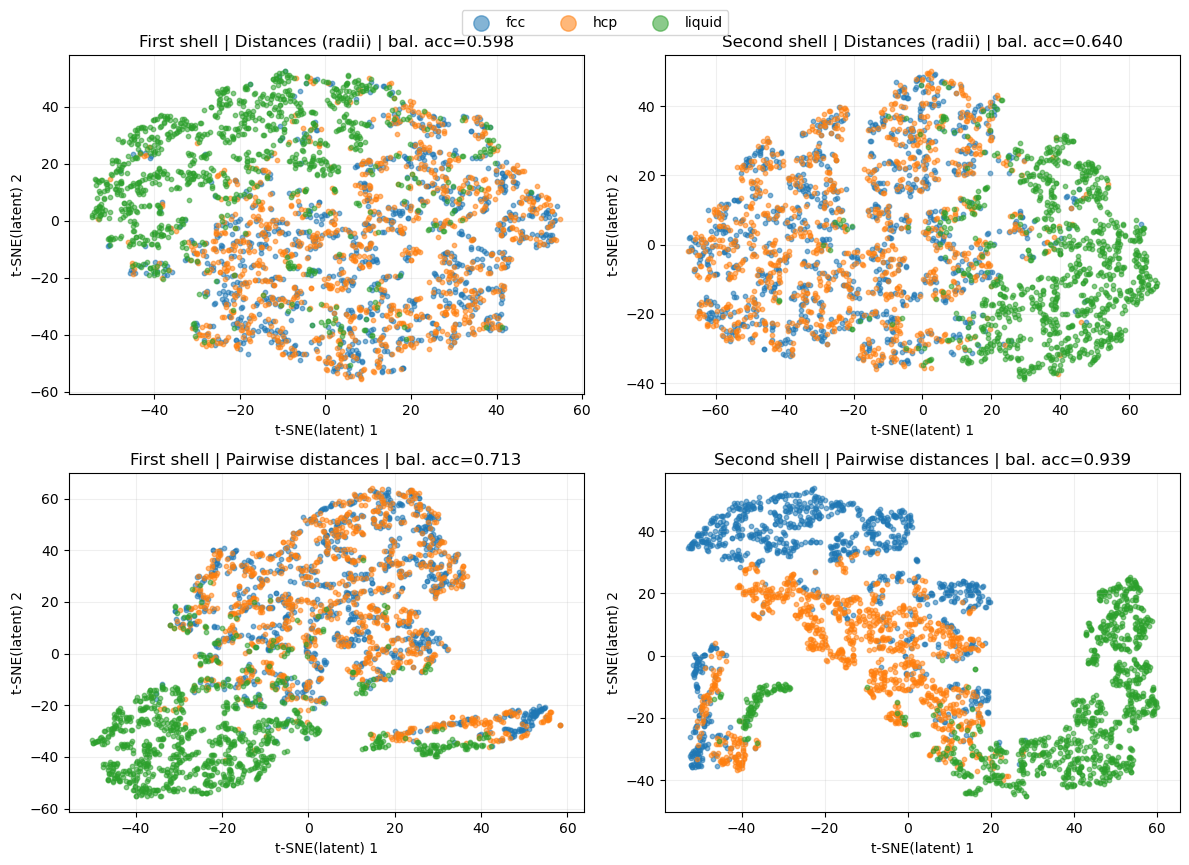

In [7]:
def sample_for_visualization(Z, y, max_samples_per_phase=MAX_VIS_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    keep = []
    for lab in sorted(np.unique(y)):
        idx = np.flatnonzero(y == lab)
        if len(idx) > max_samples_per_phase:
            idx = rng.choice(idx, size=max_samples_per_phase, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep)
    return Z[keep], y[keep]


def umap_available():
    try:
        import umap  # noqa: F401
        return True
    except ImportError:
        print("UMAP skipped: install umap-learn in this notebook kernel to enable additional UMAP plots.")
        return False


UMAP_AVAILABLE = umap_available()


def project_latent_for_plot(Z, y, method=VIS_METHOD, seed=SEED):
    Z_vis, y_vis = sample_for_visualization(Z, y)
    if method == "latent" and Z_vis.shape[1] == 2:
        return Z_vis, y_vis, "latent"
    if method == "umap":
        try:
            import umap
            n_neighbors = min(UMAP_N_NEIGHBORS, max(2, len(y_vis) - 1))
            Z_plot = umap.UMAP(
                n_components=2,
                n_neighbors=n_neighbors,
                min_dist=UMAP_MIN_DIST,
                metric="euclidean",
                random_state=seed,
            ).fit_transform(Z_vis)
            return Z_plot, y_vis, "UMAP(latent)"
        except ImportError:
            print("umap-learn is not installed; falling back to PCA for this plot.")
    if method == "tsne":
        perplexity = min(TSNE_PERPLEXITY, max(5, (len(y_vis) - 1) // 3))
        Z_plot = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=seed,
        ).fit_transform(Z_vis)
        return Z_plot, y_vis, "t-SNE(latent)"
    Z_plot = PCA(n_components=2, random_state=seed).fit_transform(Z_vis)
    return Z_plot, y_vis, "PCA(latent)"


def plot_latent_comparison(artifacts, method=VIS_METHOD):
    fig, axes = plt.subplots(len(FEATURE_KINDS), len(SHELL_ORDER), figsize=(12, 8.5), squeeze=False)
    for row, feature_kind in enumerate(FEATURE_KINDS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            art = artifacts[(shell_name, feature_kind)]
            Z_plot, y_plot, projection_label = project_latent_for_plot(art["Z"], art["y"], method=method)
            for phase in PHASES:
                lab = LABEL_MAP[phase]
                mask = y_plot == lab
                ax.scatter(
                    Z_plot[mask, 0],
                    Z_plot[mask, 1],
                    s=SCATTER_S,
                    alpha=SCATTER_ALPHA,
                    color=LABEL_COLORS[lab],
                    label=phase,
                )
            score = art["scores"]["balanced_accuracy"]
            ax.set_title(f"{SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]} | bal. acc={score:.3f}")
            ax.set_xlabel(projection_label + " 1")
            ax.set_ylabel(projection_label + " 2")
            ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(PHASES),
        bbox_to_anchor=(0.5, 1.02),
        markerscale=LEGEND_MARKERSCALE,
        fontsize=LEGEND_FONTSIZE,
    )
    plt.tight_layout()
    plt.show()

if not SKIP_AE:
    plot_latent_comparison(artifacts, method=VIS_METHOD)
    if UMAP_AVAILABLE:
        plot_latent_comparison(artifacts, method="umap")


## 5) 3-class confusion matrices

The confusion matrices use logistic regression trained on the full AE latent representation. Values are normalized by true class.


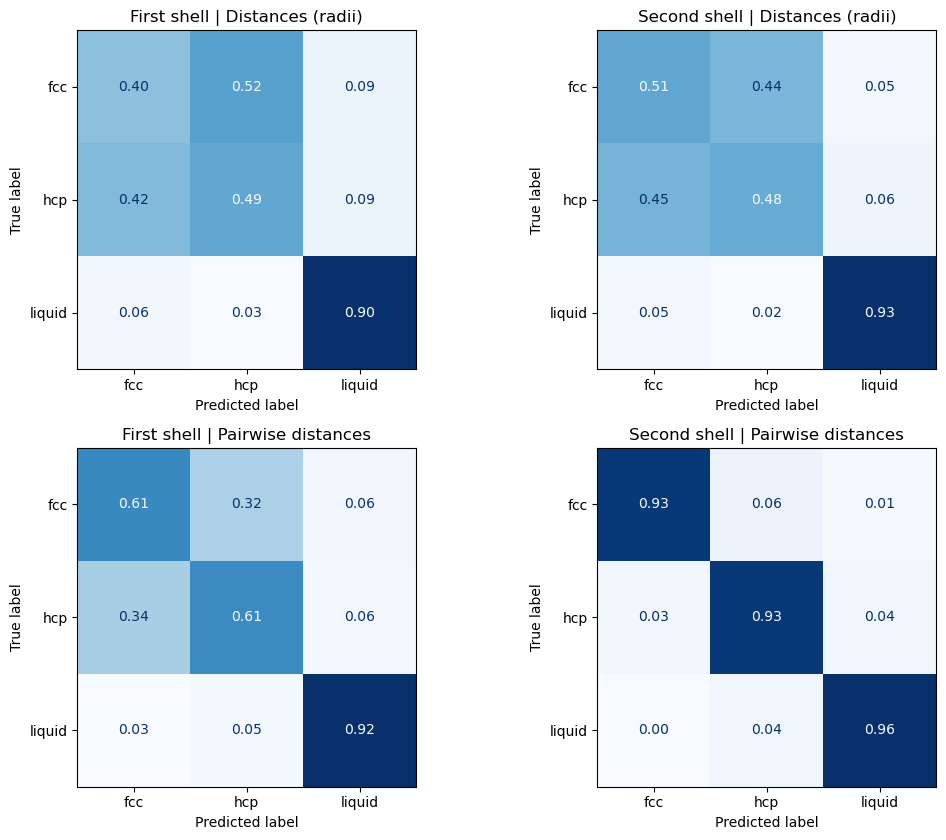

In [8]:
def plot_confusion_grid(artifacts, normalize="true"):
    fig, axes = plt.subplots(len(FEATURE_KINDS), len(SHELL_ORDER), figsize=(11, 8.5), squeeze=False)
    for row, feature_kind in enumerate(FEATURE_KINDS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            scores = artifacts[(shell_name, feature_kind)]["scores"]
            names = [LABEL_NAMES[i] for i in scores["labels"]]
            cm = confusion_matrix(
                scores["y_test"],
                scores["y_pred"],
                labels=scores["labels"],
                normalize=normalize,
            )
            disp = ConfusionMatrixDisplay(cm, display_labels=names)
            disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
            ax.set_title(f"{SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]}")
            ax.grid(False)
    plt.tight_layout()
    plt.show()

if not SKIP_AE:
    plot_confusion_grid(artifacts, normalize="true")


## 6) First-shell vs second-shell deltas

Positive deltas mean the second-shell input improved the latent-space classifier under this small shared sampling budget.


In [9]:
if not SKIP_AE:
    metric_cols = ["latent_accuracy", "latent_balanced_accuracy", "latent_macro_f1", "final_val_mse"]
    wide = scores_df.pivot(index="input_type", columns="shell", values=metric_cols)
    delta = pd.DataFrame(index=wide.index)
    for metric in metric_cols:
        delta[f"delta_{metric}"] = wide[(metric, "second_shell")] - wide[(metric, "first_shell")]
    display(delta.reset_index().round(4))


,input_type,delta_latent_accuracy,delta_latent_balanced_accuracy,delta_latent_macro_f1,delta_final_val_mse
0,pairwise_dist,0.2267,0.2267,0.2284,0.0003
1,radii,0.0419,0.0419,0.0452,0.0028


## 7) Training curves

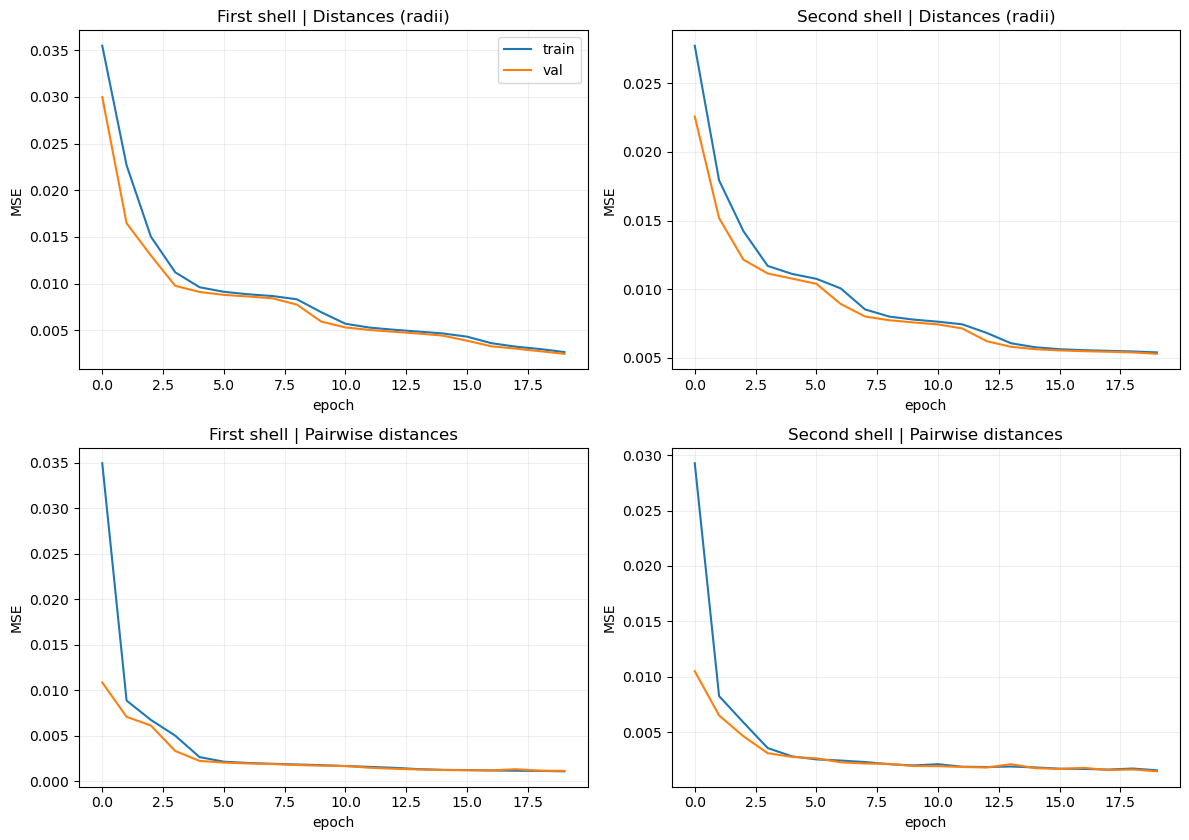

In [10]:
def plot_training_curves(artifacts):
    fig, axes = plt.subplots(len(FEATURE_KINDS), len(SHELL_ORDER), figsize=(12, 8.5), squeeze=False)
    for row, feature_kind in enumerate(FEATURE_KINDS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            hist = artifacts[(shell_name, feature_kind)]["history"]
            ax.plot(hist["loss"], label="train")
            ax.plot(hist["val_loss"], label="val")
            ax.set_title(f"{SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]}")
            ax.set_xlabel("epoch")
            ax.set_ylabel("MSE")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

if not SKIP_AE:
    plot_training_curves(artifacts)


## 8) Shallow variational autoencoder (VAE)

This experiment uses exactly the same sampled and min-max-scaled inputs as the shallow AE. The VAE encoder has a shared backbone followed by separate `mu` and `logvar` heads, and the decoder receives a reparameterized posterior sample during training.

The objective is per-sample reconstruction SSE plus `beta * KL(q(z|x) || N(0, I))`. A short KL warm-up reduces early posterior collapse; `VAE_BETA` controls the final trade-off. The `1e-2` default is deliberately reconstruction/representation-oriented; set it to `1.0` for an untempered KL term and check the reported KL and posterior standard deviation for collapse. The deterministic posterior mean `mu` is used for classification and plotting so repeated evaluation does not add sampling noise.

Implementation note: the original draft recursively called `encode()` from inside itself and sliced the batch dimension instead of the feature dimension. The corrected model above uses explicit posterior heads, which removes both problems.

In [11]:
def vae_loss_components(recon_x, x, mu, logvar, beta):
    recon_sse = F.mse_loss(recon_x, x, reduction="none").sum(dim=1).mean()
    recon_mse = F.mse_loss(recon_x, x, reduction="mean")
    kl = -0.5 * torch.sum(1.0 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    return recon_sse + beta * kl, recon_sse, recon_mse, kl


def train_shallow_vae(
    X,
    y,
    latent_dim=LATENT_DIM,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    beta=VAE_BETA,
    kl_warmup_epochs=VAE_KL_WARMUP_EPOCHS,
    seed=SEED,
):
    torch.manual_seed(seed)
    X_train, X_val, _, _ = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train)), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val)), batch_size=batch_size, shuffle=False)

    model = ShallowVAE(X.shape[1], latent_dim=latent_dim).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {
        "loss": [], "val_loss": [],
        "recon_sse": [], "val_recon_sse": [],
        "recon_mse": [], "val_recon_mse": [],
        "kl": [], "val_kl": [], "beta": [],
    }

    for epoch in range(epochs):
        if kl_warmup_epochs > 0:
            epoch_beta = beta * min(1.0, (epoch + 1) / kl_warmup_epochs)
        else:
            epoch_beta = beta
        hist["beta"].append(epoch_beta)

        model.train()
        train_sums = {key: 0.0 for key in ("loss", "recon_sse", "recon_mse", "kl")}
        for (xb,) in train_loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            recon_x, mu, logvar = model(xb)
            values = vae_loss_components(recon_x, xb, mu, logvar, epoch_beta)
            loss, recon_sse, recon_mse, kl = values
            loss.backward()
            opt.step()
            for key, value in zip(train_sums, values):
                train_sums[key] += value.item() * xb.size(0)
        for key, value in train_sums.items():
            hist[key].append(value / len(train_loader.dataset))

        model.eval()
        val_sums = {key: 0.0 for key in ("loss", "recon_sse", "recon_mse", "kl")}
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(DEVICE)
                recon_x, mu, logvar = model(xb)
                values = vae_loss_components(recon_x, xb, mu, logvar, epoch_beta)
                for key, value in zip(val_sums, values):
                    val_sums[key] += value.item() * xb.size(0)
        for key, value in val_sums.items():
            hist[f"val_{key}"].append(value / len(val_loader.dataset))

    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(torch.tensor(X, dtype=torch.float32).to(DEVICE))
        Z = mu.cpu().numpy()
        posterior_std = torch.exp(0.5 * logvar).cpu().numpy()
    return model, hist, Z, posterior_std


def run_vae_suite(shell_data):
    rows = []
    vae_artifacts = {}
    for shell_name in SHELL_ORDER:
        for feature_kind in FEATURE_KINDS:
            print(f"Training VAE: {SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]}")
            X, y, scaler = make_ae_data(shell_data[shell_name], feature_kind, PHASES)
            model, hist, Z, posterior_std = train_shallow_vae(X, y)
            scores = score_latent_classifier(Z, y)
            diag = latent_diagnostics(Z)
            rows.append({
                "shell": shell_name,
                "input_type": feature_kind,
                "n_samples": len(y),
                "input_dim": X.shape[1],
                "latent_dim": Z.shape[1],
                "beta": hist["beta"][-1],
                "final_val_mse": hist["val_recon_mse"][-1],
                "final_val_vae_loss": hist["val_loss"][-1],
                "final_val_kl": hist["val_kl"][-1],
                "posterior_std_mean": float(posterior_std.mean()),
                "latent_accuracy": scores["accuracy"],
                "latent_balanced_accuracy": scores["balanced_accuracy"],
                "latent_macro_f1": scores["macro_f1"],
                **diag,
            })
            vae_artifacts[(shell_name, feature_kind)] = {
                "X": X, "y": y, "scaler": scaler, "model": model,
                "history": hist, "Z": Z, "posterior_std": posterior_std,
                "scores": scores, "diagnostics": diag,
            }
    return pd.DataFrame(rows), vae_artifacts


if not SKIP_VAE:
    vae_scores_df, vae_artifacts = run_vae_suite(shell_data)
    display(vae_scores_df.sort_values(["input_type", "shell"]).round(4))


Training VAE: First shell | Distances (radii)
Training VAE: First shell | Pairwise distances
Training VAE: Second shell | Distances (radii)
Training VAE: Second shell | Pairwise distances


,shell,input_type,n_samples,input_dim,latent_dim,beta,final_val_mse,final_val_vae_loss,final_val_kl,posterior_std_mean,latent_accuracy,latent_balanced_accuracy,latent_macro_f1,latent_std_mean,latent_std_min,latent_abs_mean
1,first_shell,pairwise_dist,18000,78,8,0.01,0.0016,0.1674,4.4177,0.6681,0.7069,0.7069,0.7073,0.4112,0.0591,0.2985
3,second_shell,pairwise_dist,18000,171,8,0.01,0.0017,0.3590,6.7782,0.5848,0.8783,0.8783,0.8786,0.5626,0.0510,0.4876
0,first_shell,radii,18000,12,8,0.01,0.0055,0.0914,2.4910,0.8096,0.6025,0.6025,0.5937,0.3043,0.0464,0.2463
2,second_shell,radii,18000,18,8,0.01,0.0073,0.1625,3.1297,0.7443,0.6433,0.6433,0.6397,0.5131,0.2357,0.4221


## 9) VAE latent representation comparison

As for the AE, the linear probe uses the full posterior-mean vector; t-SNE/UMAP/PCA is only a 2D display projection.

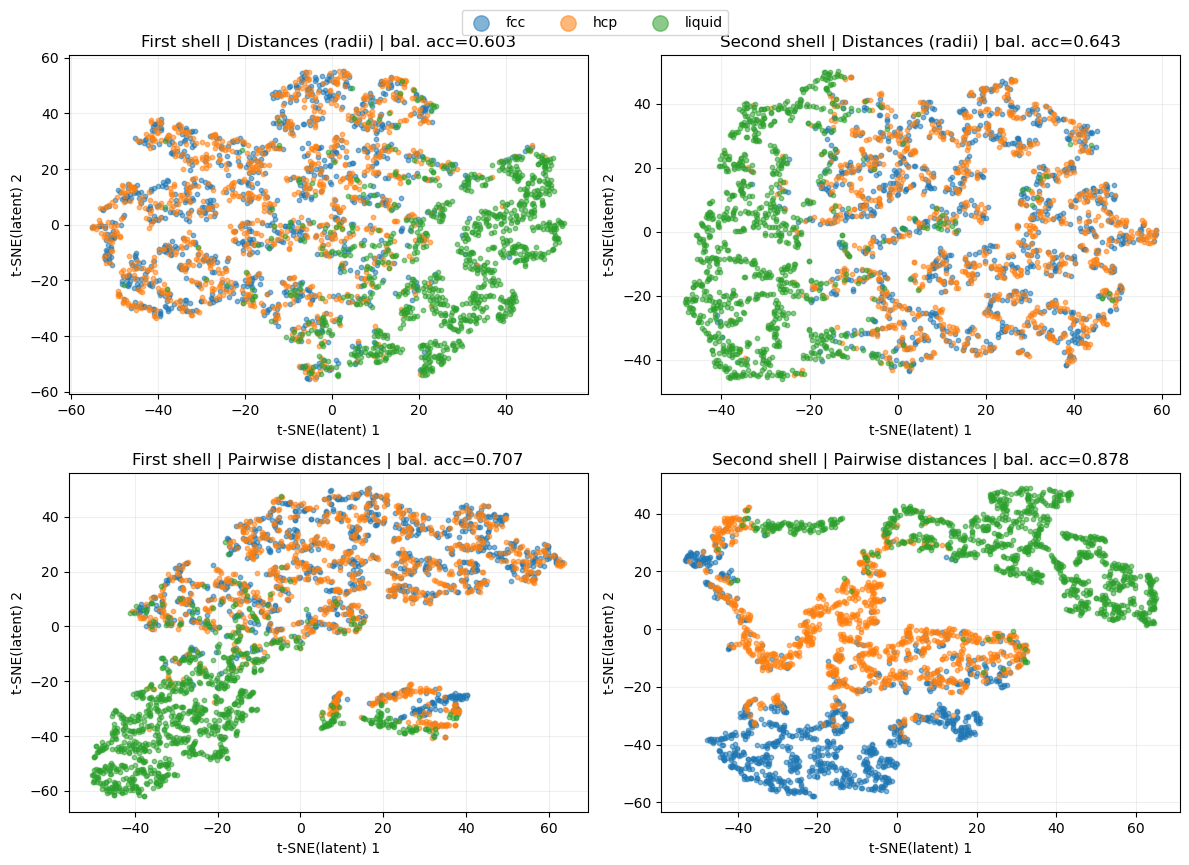

In [12]:
if not SKIP_VAE:
    plot_latent_comparison(vae_artifacts, method=VIS_METHOD)
    if UMAP_AVAILABLE:
        plot_latent_comparison(vae_artifacts, method="umap")


## 10) VAE 3-class confusion matrices

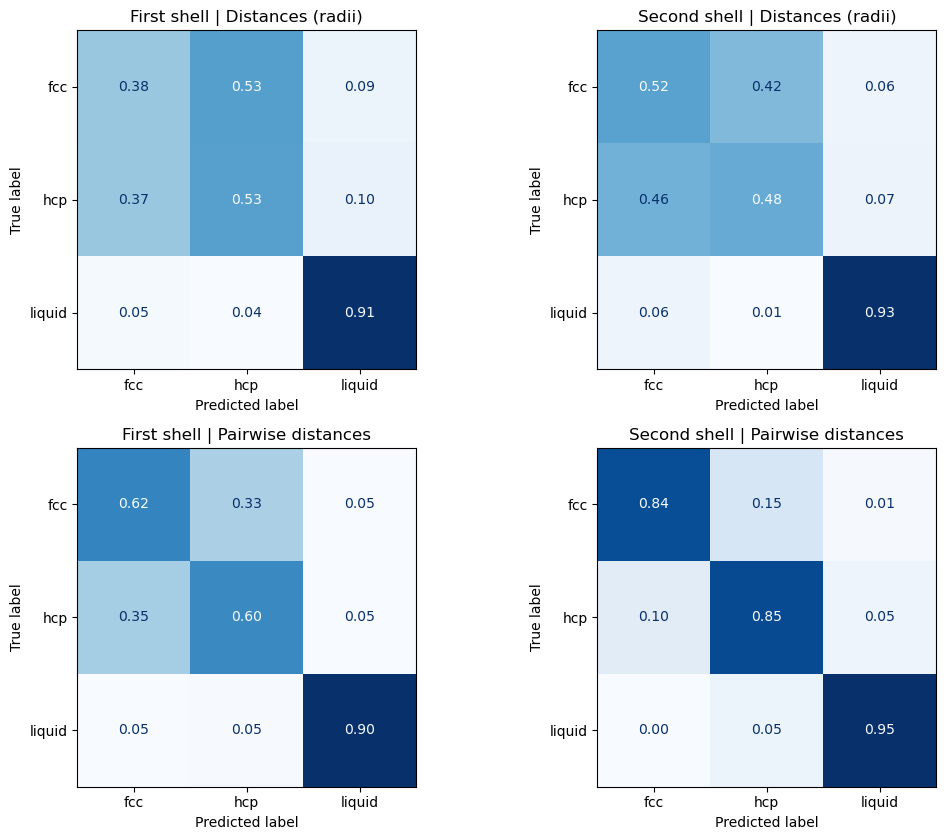

In [13]:
if not SKIP_VAE:
    plot_confusion_grid(vae_artifacts, normalize="true")


## 11) VAE first-shell vs second-shell deltas

In [14]:
if not SKIP_VAE:
    vae_metric_cols = [
        "latent_accuracy", "latent_balanced_accuracy", "latent_macro_f1",
        "final_val_mse", "final_val_vae_loss", "final_val_kl",
    ]
    vae_wide = vae_scores_df.pivot(index="input_type", columns="shell", values=vae_metric_cols)
    vae_delta = pd.DataFrame(index=vae_wide.index)
    for metric in vae_metric_cols:
        vae_delta[f"delta_{metric}"] = (
            vae_wide[(metric, "second_shell")] - vae_wide[(metric, "first_shell")]
        )
    display(vae_delta.reset_index().round(4))


,input_type,delta_latent_accuracy,delta_latent_balanced_accuracy,delta_latent_macro_f1,delta_final_val_mse,delta_final_val_vae_loss,delta_final_val_kl
0,pairwise_dist,0.1714,0.1714,0.1713,0.0001,0.1916,2.3605
1,radii,0.0408,0.0408,0.0460,0.0018,0.0712,0.6388


## 12) VAE training curves

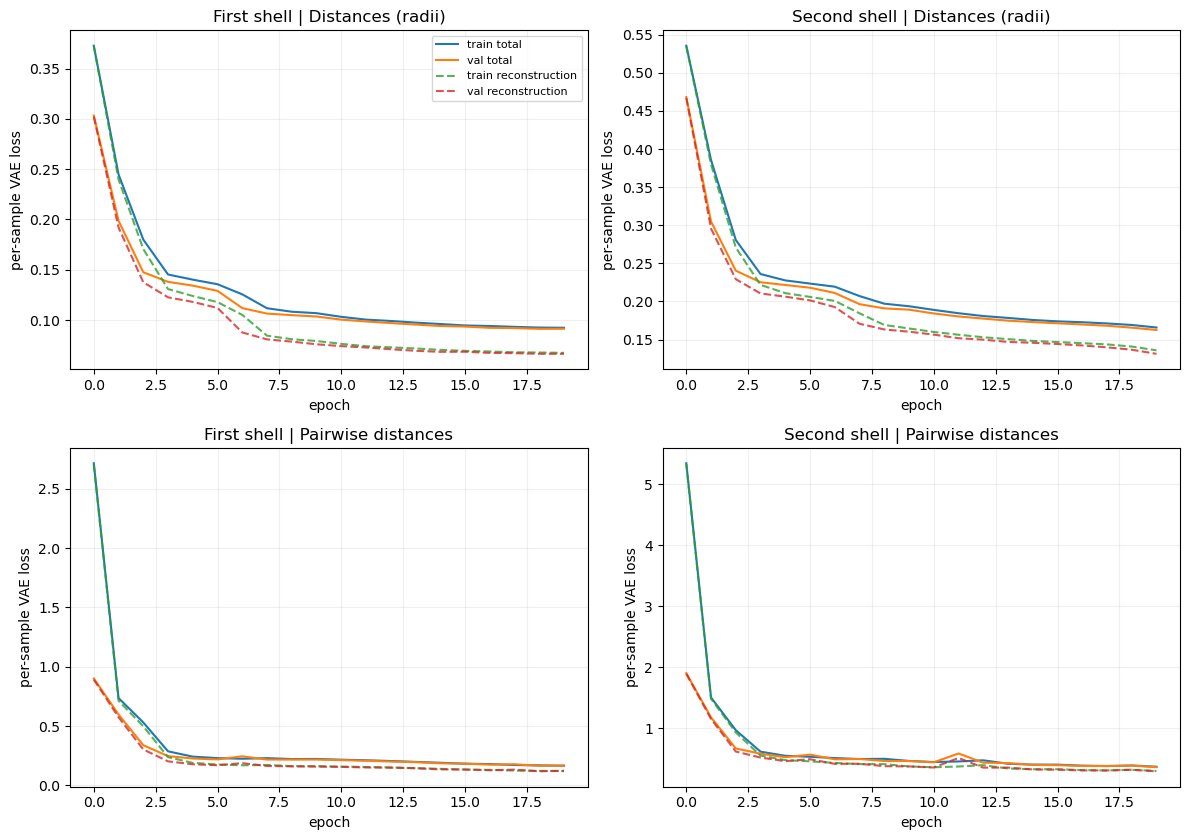

In [15]:
def plot_vae_training_curves(vae_artifacts):
    fig, axes = plt.subplots(len(FEATURE_KINDS), len(SHELL_ORDER), figsize=(12, 8.5), squeeze=False)
    for row, feature_kind in enumerate(FEATURE_KINDS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            hist = vae_artifacts[(shell_name, feature_kind)]["history"]
            ax.plot(hist["loss"], label="train total")
            ax.plot(hist["val_loss"], label="val total")
            ax.plot(hist["recon_sse"], "--", alpha=0.8, label="train reconstruction")
            ax.plot(hist["val_recon_sse"], "--", alpha=0.8, label="val reconstruction")
            ax.set_title(f"{SHELL_LABELS[shell_name]} | {FEATURE_LABELS[feature_kind]}")
            ax.set_xlabel("epoch")
            ax.set_ylabel("per-sample VAE loss")
            ax.grid(alpha=0.2)
    axes[0, 0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


if not SKIP_VAE:
    plot_vae_training_curves(vae_artifacts)


## 13) EGNN invariant autoencoder

This section compares first-shell and second-shell neighbourhoods with an EGNN encoder.

The permutation-invariant decoder design is the important part: the encoder receives the unordered neighbour coordinate cloud, but the decoder reconstructs an invariant distance signature instead of ordered coordinates:

- sorted all-pairwise distances over `central + neighbours`

This includes the radii implicitly and avoids a point-assignment problem in the decoder while still forcing the latent vector to encode the local metric geometry. The linear probe and confusion matrices use the EGNN latent vectors; t-SNE is only used for plotting.


In [16]:
# EGNN configuration
EGNN_MAX_SAMPLES_PER_PHASE = 100000
EGNN_EPOCHS = 25
EGNN_BATCH_SIZE = 256
EGNN_LR = 1e-3
EGNN_WEIGHT_DECAY = 1e-4
EGNN_LATENT_DIM = 4
EGNN_FEAT_DIM = 48
EGNN_N_LAYERS = 4
EGNN_COORD_SCALE = 0.05
EGNN_GRAD_CLIP = 5.0
EGNN_VIS_METHOD = "tsne"  # "tsne", "umap", or "pca"
EGNN_MAX_VIS_SAMPLES_PER_PHASE = 800


In [17]:
class EGNNMLP(nn.Module):
    def __init__(self, dims, act=nn.SiLU, final_act=False):
        super().__init__()
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2 or final_act:
                layers.append(act())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class EGNNLayer(nn.Module):
    def __init__(self, feat_dim, hidden_dim=48, coord_scale=EGNN_COORD_SCALE):
        super().__init__()
        self.edge_mlp = EGNNMLP([2 * feat_dim + 1, hidden_dim, hidden_dim, hidden_dim])
        self.coord_mlp = EGNNMLP([hidden_dim, hidden_dim, 1])
        self.node_mlp = EGNNMLP([feat_dim + hidden_dim, hidden_dim, feat_dim])
        self.norm = nn.LayerNorm(feat_dim)
        self.coord_scale = coord_scale

    def forward(self, h, x, edge_index):
        row, col = edge_index
        hi = h[:, row, :]
        hj = h[:, col, :]
        rel = x[:, row, :] - x[:, col, :]
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)

        m_ij = self.edge_mlp(torch.cat([hi, hj, dist2], dim=-1))
        coord_coeff = torch.tanh(self.coord_mlp(m_ij))
        trans = rel * coord_coeff
        agg_trans = torch.zeros(x.shape[0], x.shape[1], 3, device=x.device, dtype=x.dtype)
        agg_trans.index_add_(1, row, trans)
        x = x + self.coord_scale * agg_trans / max(1, x.shape[1] - 1)

        agg_m = torch.zeros(h.shape[0], h.shape[1], m_ij.shape[-1], device=h.device, dtype=h.dtype)
        agg_m.index_add_(1, row, m_ij)
        agg_m = agg_m / max(1, h.shape[1] - 1)

        h = h + self.node_mlp(torch.cat([h, agg_m], dim=-1))
        return self.norm(h), x


class EGNNEncoder(nn.Module):
    def __init__(self, n_layers=EGNN_N_LAYERS, feat_dim=EGNN_FEAT_DIM, latent_dim=EGNN_LATENT_DIM):
        super().__init__()
        # Node feature is radius to the central particle; geometry enters through coordinates and dist2 messages.
        self.node_embed = nn.Sequential(nn.Linear(1, feat_dim), nn.SiLU(), nn.Linear(feat_dim, feat_dim))
        self.layers = nn.ModuleList([EGNNLayer(feat_dim, feat_dim) for _ in range(n_layers)])
        self.to_latent = EGNNMLP([2 * feat_dim, feat_dim, feat_dim, latent_dim])

    def forward(self, x, edge_index):
        radii = torch.linalg.norm(x, dim=-1, keepdim=True)
        h = self.node_embed(radii)
        for layer in self.layers:
            h, x = layer(h, x, edge_index)

        pooled_mean = h.mean(dim=1)
        pooled_max = h.max(dim=1).values
        return self.to_latent(torch.cat([pooled_mean, pooled_max], dim=-1))


class InvariantSignatureDecoder(nn.Module):
    def __init__(self, latent_dim, out_dim, hidden_dim=EGNN_FEAT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            EGNNMLP([latent_dim, hidden_dim, hidden_dim, hidden_dim, out_dim]),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


class InvariantEGNNAE(nn.Module):
    def __init__(self, n_points, latent_dim=EGNN_LATENT_DIM, feat_dim=EGNN_FEAT_DIM, n_layers=EGNN_N_LAYERS):
        super().__init__()
        self.n_points = n_points
        self.out_dim = n_points * (n_points - 1) // 2
        self.encoder = EGNNEncoder(n_layers=n_layers, feat_dim=feat_dim, latent_dim=latent_dim)
        self.decoder = InvariantSignatureDecoder(latent_dim, self.out_dim, hidden_dim=feat_dim)

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        return self.decoder(z), z


def make_fully_connected_edges(n_nodes):
    row, col = [], []
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                row.append(i)
                col.append(j)
    return torch.tensor([row, col], dtype=torch.long)


def invariant_signature_torch(x):
    dmat = torch.cdist(x, x, p=2)
    upper = torch.triu_indices(x.shape[1], x.shape[1], offset=1, device=x.device)
    return torch.sort(dmat[:, upper[0], upper[1]], dim=1).values


def invariant_signature_numpy(x):
    diffs = x[:, :, None, :] - x[:, None, :, :]
    dist = np.linalg.norm(diffs, axis=-1)
    upper = np.triu_indices(x.shape[1], k=1)
    return np.sort(dist[:, upper[0], upper[1]], axis=1).astype(np.float32)


def scale_coords_by_median_radius(X):
    radii = np.linalg.norm(X, axis=-1).reshape(-1)
    scale = np.median(radii)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    return (X / scale).astype(np.float32), float(scale)


def make_egnn_data(data_by_phase, max_samples_per_phase=EGNN_MAX_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for phase in PHASES:
        X = data_by_phase[phase]["vec_dist"]
        n = X.shape[0]
        if max_samples_per_phase is not None and n > max_samples_per_phase:
            idx = rng.choice(n, size=max_samples_per_phase, replace=False)
            X = X[idx]
        y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)
        Xs.append(X.astype(np.float32))
        ys.append(y)

    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    X = with_central_point(X)
    X_scaled, coord_scale = scale_coords_by_median_radius(X)
    return X_scaled, y, coord_scale


def train_egnn_ae(X, y, epochs=EGNN_EPOCHS, batch_size=EGNN_BATCH_SIZE, seed=SEED):
    torch.manual_seed(seed)
    target_scaler = MinMaxScaler()
    target = target_scaler.fit_transform(invariant_signature_numpy(X)).astype(np.float32)

    X_train, X_val, target_train, target_val = train_test_split(
        X, target, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(target_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(target_val)),
        batch_size=batch_size,
        shuffle=False,
    )

    n_points = X.shape[1]
    edge_index = make_fully_connected_edges(n_points).to(DEVICE)
    model = InvariantEGNNAE(n_points=n_points).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=EGNN_LR, weight_decay=EGNN_WEIGHT_DECAY)
    hist = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, target in train_loader:
            xb = xb.to(DEVICE)
            target = target.to(DEVICE)
            pred, _ = model(xb, edge_index)
            loss = F.mse_loss(pred, target)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), EGNN_GRAD_CLIP)
            opt.step()
            total += loss.item() * xb.size(0)
        hist["loss"].append(total / len(train_loader.dataset))

        model.eval()
        total = 0.0
        with torch.no_grad():
            for xb, target in val_loader:
                xb = xb.to(DEVICE)
                target = target.to(DEVICE)
                pred, _ = model(xb, edge_index)
                total += F.mse_loss(pred, target).item() * xb.size(0)
        hist["val_loss"].append(total / len(val_loader.dataset))

        if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"epoch {epoch + 1:03d} | train={hist['loss'][-1]:.5f} | val={hist['val_loss'][-1]:.5f}")

    model.eval()
    zs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32, device=DEVICE)
            zs.append(model.encode(xb, edge_index).cpu().numpy())
    Z = np.concatenate(zs, axis=0)
    return model, hist, Z, edge_index, target_scaler


In [18]:
def run_egnn_suite(shell_data):
    rows = []
    artifacts = {}
    for shell_name in SHELL_ORDER:
        print("=" * 72)
        print(f"EGNN AE | {SHELL_LABELS[shell_name]}")
        print("=" * 72)
        X, y, coord_scale = make_egnn_data(shell_data[shell_name])
        model, hist, Z, edge_index, target_scaler = train_egnn_ae(X, y)
        scores = score_latent_classifier(Z, y)
        diag = latent_diagnostics(Z)

        rows.append({
            "shell": shell_name,
            "n_samples": len(y),
            "n_points": X.shape[1],
            "target_dim": X.shape[1] * (X.shape[1] - 1) // 2,
            "latent_dim": Z.shape[1],
            "coord_scale": coord_scale,
            "final_val_loss": hist["val_loss"][-1],
            "latent_accuracy": scores["accuracy"],
            "latent_balanced_accuracy": scores["balanced_accuracy"],
            "latent_macro_f1": scores["macro_f1"],
            **diag,
        })
        artifacts[shell_name] = {
            "X": X,
            "y": y,
            "model": model,
            "history": hist,
            "Z": Z,
            "scores": scores,
            "edge_index": edge_index,
            "coord_scale": coord_scale,
            "target_scaler": target_scaler,
        }
    return pd.DataFrame(rows), artifacts

if not SKIP_EGNN_NORMAL:
    egnn_scores_df, egnn_artifacts = run_egnn_suite(shell_data)
    display(egnn_scores_df.round(4))


EGNN AE | First shell
epoch 001 | train=0.00436 | val=0.00129
epoch 005 | train=0.00097 | val=0.00094
epoch 010 | train=0.00073 | val=0.00072
epoch 015 | train=0.00067 | val=0.00068
epoch 020 | train=0.00059 | val=0.00058
epoch 025 | train=0.00056 | val=0.00056
EGNN AE | Second shell
epoch 001 | train=0.00480 | val=0.00142
epoch 005 | train=0.00099 | val=0.00102
epoch 010 | train=0.00068 | val=0.00065
epoch 015 | train=0.00053 | val=0.00055
epoch 020 | train=0.00049 | val=0.00048
epoch 025 | train=0.00047 | val=0.00048


,shell,n_samples,n_points,target_dim,latent_dim,coord_scale,final_val_loss,latent_accuracy,latent_balanced_accuracy,latent_macro_f1,latent_std_mean,latent_std_min,latent_abs_mean
0,first_shell,290300,13,78,4,1.0534,0.0006,0.6377,0.6453,0.6426,1.7332,1.3711,2.6764
1,second_shell,290300,19,171,4,1.1153,0.0005,0.8740,0.8753,0.8756,2.2337,1.7658,2.7855


## 14) EGNN latent comparison and confusion matrices

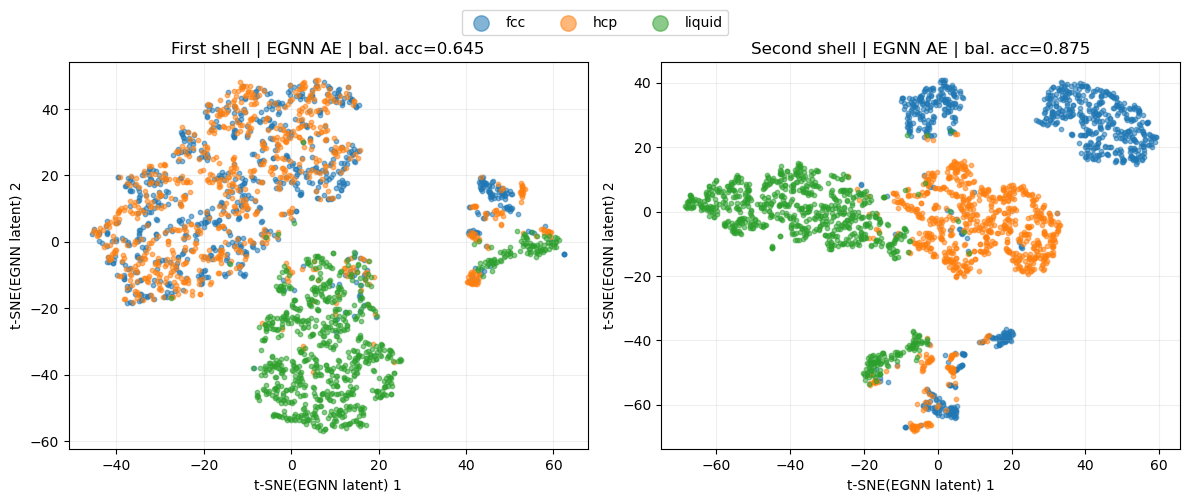

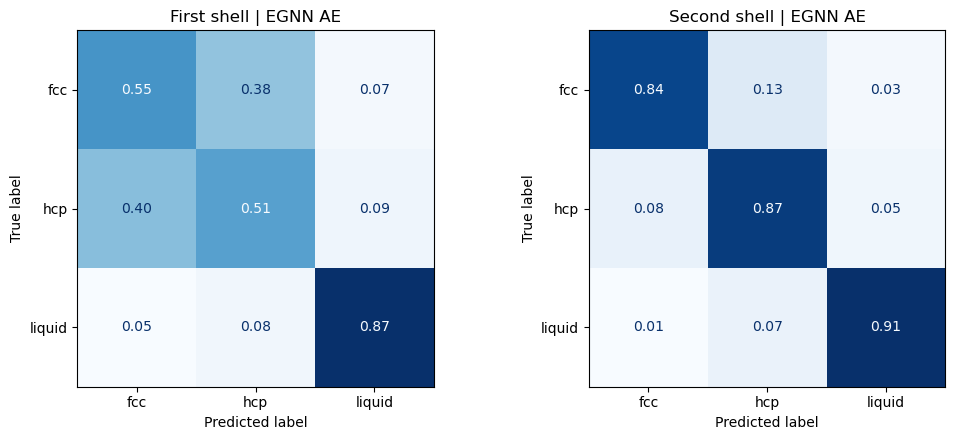

In [19]:
def sample_egnn_for_visualization(Z, y, max_samples_per_phase=EGNN_MAX_VIS_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    keep = []
    for lab in sorted(np.unique(y)):
        idx = np.flatnonzero(y == lab)
        if len(idx) > max_samples_per_phase:
            idx = rng.choice(idx, size=max_samples_per_phase, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep)
    return Z[keep], y[keep]


def project_egnn_latent_for_plot(Z, y, method=EGNN_VIS_METHOD, seed=SEED):
    Z_vis, y_vis = sample_egnn_for_visualization(Z, y, max_samples_per_phase=EGNN_MAX_VIS_SAMPLES_PER_PHASE, seed=seed)
    if method == "umap":
        try:
            import umap
            n_neighbors = min(UMAP_N_NEIGHBORS, max(2, len(y_vis) - 1))
            Z_plot = umap.UMAP(
                n_components=2,
                n_neighbors=n_neighbors,
                min_dist=UMAP_MIN_DIST,
                metric="euclidean",
                random_state=seed,
            ).fit_transform(Z_vis)
            return Z_plot, y_vis, "UMAP(EGNN latent)"
        except ImportError:
            print("umap-learn is not installed; falling back to PCA for this plot.")
    if method == "tsne":
        perplexity = min(TSNE_PERPLEXITY, max(5, (len(y_vis) - 1) // 3))
        Z_plot = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=seed,
        ).fit_transform(Z_vis)
        return Z_plot, y_vis, "t-SNE(EGNN latent)"
    return PCA(n_components=2, random_state=seed).fit_transform(Z_vis), y_vis, "PCA(EGNN latent)"


def plot_egnn_latents(artifacts, method=EGNN_VIS_METHOD):
    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(12, 4.8), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        art = artifacts[shell_name]
        Z_plot, y_plot, projection_label = project_egnn_latent_for_plot(art["Z"], art["y"], method=method)
        for phase in PHASES:
            lab = LABEL_MAP[phase]
            mask = y_plot == lab
            ax.scatter(
                Z_plot[mask, 0],
                Z_plot[mask, 1],
                s=SCATTER_S,
                alpha=SCATTER_ALPHA,
                color=LABEL_COLORS[lab],
                label=phase,
            )
        score = art["scores"]["balanced_accuracy"]
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN AE | bal. acc={score:.3f}")
        ax.set_xlabel(projection_label + " 1")
        ax.set_ylabel(projection_label + " 2")
        ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(PHASES),
        bbox_to_anchor=(0.5, 1.05),
        markerscale=LEGEND_MARKERSCALE,
        fontsize=LEGEND_FONTSIZE,
    )
    plt.tight_layout()
    plt.show()


def plot_egnn_confusions(artifacts, normalize="true"):
    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(10.5, 4.5), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        scores = artifacts[shell_name]["scores"]
        names = [LABEL_NAMES[i] for i in scores["labels"]]
        cm = confusion_matrix(
            scores["y_test"],
            scores["y_pred"],
            labels=scores["labels"],
            normalize=normalize,
        )
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN AE")
        ax.grid(False)
    plt.tight_layout()
    plt.show()

if not SKIP_EGNN_NORMAL:
    plot_egnn_latents(egnn_artifacts, method=EGNN_VIS_METHOD)
    if globals().get("UMAP_AVAILABLE", False):
        plot_egnn_latents(egnn_artifacts, method="umap")
    plot_egnn_confusions(egnn_artifacts, normalize="true")


## 15) EGNN first-shell vs second-shell delta

,delta_latent_accuracy,delta_latent_balanced_accuracy,delta_latent_macro_f1,delta_final_val_loss
0,0.2363,0.23,0.233,-0.0001


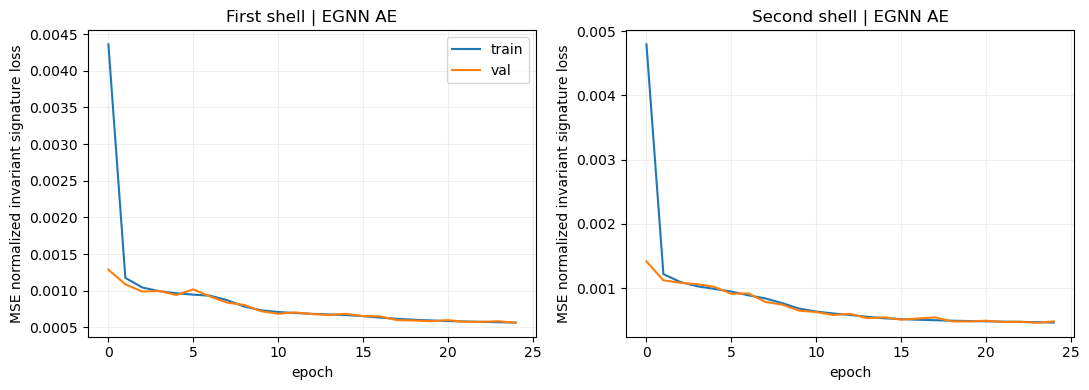

In [20]:
if not SKIP_EGNN_NORMAL:
    egnn_metric_cols = ["latent_accuracy", "latent_balanced_accuracy", "latent_macro_f1", "final_val_loss"]
    egnn_wide = egnn_scores_df.set_index("shell")[egnn_metric_cols]
    egnn_delta = {
        f"delta_{metric}": egnn_wide.loc["second_shell", metric] - egnn_wide.loc["first_shell", metric]
        for metric in egnn_metric_cols
    }
    display(pd.DataFrame([egnn_delta]).round(4))

    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(11, 4), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        hist = egnn_artifacts[shell_name]["history"]
        ax.plot(hist["loss"], label="train")
        ax.plot(hist["val_loss"], label="val")
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN AE")
        ax.set_xlabel("epoch")
        ax.set_ylabel("MSE normalized invariant signature loss")
        ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()


## 16) EGNN autoencoder with q_l reconstruction target

The distance-signature EGNN target can reconstruct geometry while still not emphasizing the fcc/hcp distinction strongly enough. This variant keeps the same EGNN encoder and probe, but decodes the per-particle `q_l` vector from the NPZ file.

This is still unsupervised with respect to phase labels, but the reconstruction target is now a known order-parameter representation, so the latent has a stronger incentive to preserve class-relevant angular-order information.


In [21]:
# q_l target EGNN configuration. Reuses EGNN_MAX_SAMPLES_PER_PHASE, EGNN_EPOCHS, etc.
QL_TARGET_KEY = "ql"


In [22]:
class EGNNQLAE(nn.Module):
    def __init__(self, target_dim, latent_dim=EGNN_LATENT_DIM, feat_dim=EGNN_FEAT_DIM, n_layers=EGNN_N_LAYERS):
        super().__init__()
        self.encoder = EGNNEncoder(n_layers=n_layers, feat_dim=feat_dim, latent_dim=latent_dim)
        self.decoder = InvariantSignatureDecoder(latent_dim, target_dim, hidden_dim=feat_dim)

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        return self.decoder(z), z


def make_egnn_ql_data(data_by_phase, target_key=QL_TARGET_KEY, max_samples_per_phase=EGNN_MAX_SAMPLES_PER_PHASE, seed=SEED):
    rng = np.random.default_rng(seed)
    Xs, ys, targets = [], [], []
    for phase in PHASES:
        X = data_by_phase[phase]["vec_dist"]
        target = data_by_phase[phase][target_key]
        n = X.shape[0]
        if max_samples_per_phase is not None and n > max_samples_per_phase:
            idx = rng.choice(n, size=max_samples_per_phase, replace=False)
            X = X[idx]
            target = target[idx]
        y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)
        Xs.append(X.astype(np.float32))
        targets.append(target.astype(np.float32))
        ys.append(y)

    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    target = np.concatenate(targets, axis=0)

    X = with_central_point(X)
    X_scaled, coord_scale = scale_coords_by_median_radius(X)

    target_scaler = MinMaxScaler()
    target_scaled = target_scaler.fit_transform(target).astype(np.float32)
    return X_scaled, y, target_scaled, coord_scale, target_scaler


def train_egnn_ql_ae(X, y, target, epochs=EGNN_EPOCHS, batch_size=EGNN_BATCH_SIZE, seed=SEED):
    torch.manual_seed(seed)
    X_train, X_val, target_train, target_val = train_test_split(
        X, target, test_size=0.2, random_state=seed, stratify=y, shuffle=True
    )
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(target_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(target_val)),
        batch_size=batch_size,
        shuffle=False,
    )

    n_points = X.shape[1]
    edge_index = make_fully_connected_edges(n_points).to(DEVICE)
    model = EGNNQLAE(target_dim=target.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=EGNN_LR, weight_decay=EGNN_WEIGHT_DECAY)
    hist = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, target_b in train_loader:
            xb = xb.to(DEVICE)
            target_b = target_b.to(DEVICE)
            pred, _ = model(xb, edge_index)
            loss = F.mse_loss(pred, target_b)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), EGNN_GRAD_CLIP)
            opt.step()
            total += loss.item() * xb.size(0)
        hist["loss"].append(total / len(train_loader.dataset))

        model.eval()
        total = 0.0
        with torch.no_grad():
            for xb, target_b in val_loader:
                xb = xb.to(DEVICE)
                target_b = target_b.to(DEVICE)
                pred, _ = model(xb, edge_index)
                total += F.mse_loss(pred, target_b).item() * xb.size(0)
        hist["val_loss"].append(total / len(val_loader.dataset))

        if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"epoch {epoch + 1:03d} | train={hist['loss'][-1]:.5f} | val={hist['val_loss'][-1]:.5f}")

    model.eval()
    zs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32, device=DEVICE)
            zs.append(model.encode(xb, edge_index).cpu().numpy())
    Z = np.concatenate(zs, axis=0)
    return model, hist, Z, edge_index


In [23]:
def run_egnn_ql_suite(shell_data):
    rows = []
    artifacts = {}
    for shell_name in SHELL_ORDER:
        print("=" * 72)
        print(f"EGNN q_l AE | {SHELL_LABELS[shell_name]}")
        print("=" * 72)
        X, y, target, coord_scale, target_scaler = make_egnn_ql_data(shell_data[shell_name])
        model, hist, Z, edge_index = train_egnn_ql_ae(X, y, target)
        scores = score_latent_classifier(Z, y)
        diag = latent_diagnostics(Z)

        rows.append({
            "shell": shell_name,
            "target": QL_TARGET_KEY,
            "n_samples": len(y),
            "n_points": X.shape[1],
            "target_dim": target.shape[1],
            "latent_dim": Z.shape[1],
            "coord_scale": coord_scale,
            "final_val_loss": hist["val_loss"][-1],
            "latent_accuracy": scores["accuracy"],
            "latent_balanced_accuracy": scores["balanced_accuracy"],
            "latent_macro_f1": scores["macro_f1"],
            **diag,
        })
        artifacts[shell_name] = {
            "X": X,
            "y": y,
            "target": target,
            "target_scaler": target_scaler,
            "model": model,
            "history": hist,
            "Z": Z,
            "scores": scores,
            "edge_index": edge_index,
            "coord_scale": coord_scale,
        }
    return pd.DataFrame(rows), artifacts

if not SKIP_EGNN_QL:
    egnn_ql_scores_df, egnn_ql_artifacts = run_egnn_ql_suite(shell_data)
    display(egnn_ql_scores_df.round(4))


EGNN q_l AE | First shell
epoch 001 | train=0.01717 | val=0.01418
epoch 005 | train=0.01240 | val=0.01216
epoch 010 | train=0.00909 | val=0.00881
epoch 015 | train=0.00822 | val=0.00819
epoch 020 | train=0.00788 | val=0.00777
epoch 025 | train=0.00772 | val=0.00764
EGNN q_l AE | Second shell
epoch 001 | train=0.01796 | val=0.01443
epoch 005 | train=0.00878 | val=0.00868
epoch 010 | train=0.00809 | val=0.00804
epoch 015 | train=0.00776 | val=0.00769
epoch 020 | train=0.00739 | val=0.00733
epoch 025 | train=0.00718 | val=0.00726


,shell,target,n_samples,n_points,target_dim,latent_dim,coord_scale,final_val_loss,latent_accuracy,latent_balanced_accuracy,latent_macro_f1,latent_std_mean,latent_std_min,latent_abs_mean
0,first_shell,ql,290300,13,20,4,1.0534,0.0076,0.9916,0.9915,0.9915,1.7553,1.2840,1.5106
1,second_shell,ql,290300,19,20,4,1.1153,0.0073,0.9975,0.9975,0.9975,1.7589,0.9778,1.4713


## 17) q_l-target EGNN latent comparison and confusion matrices

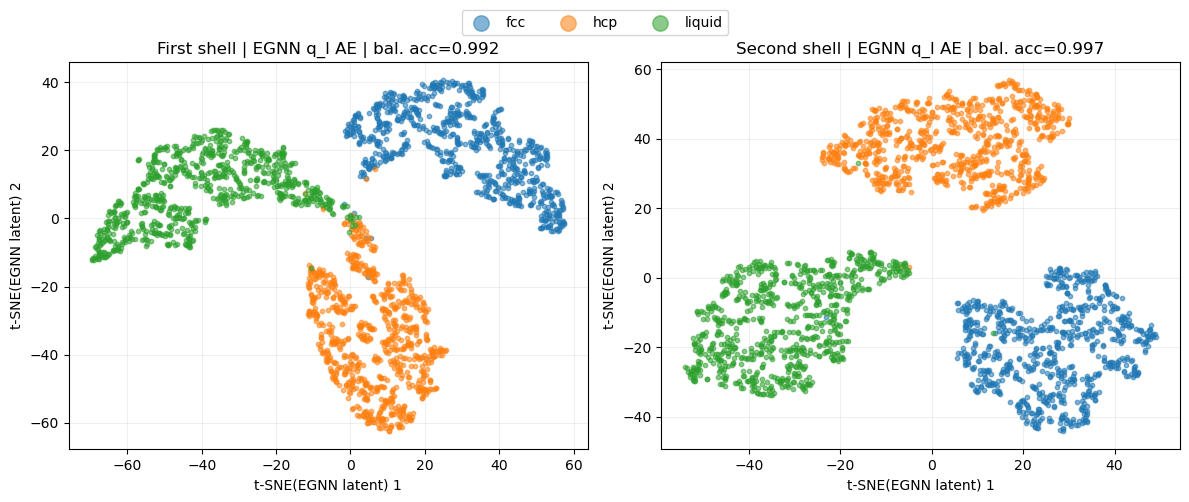

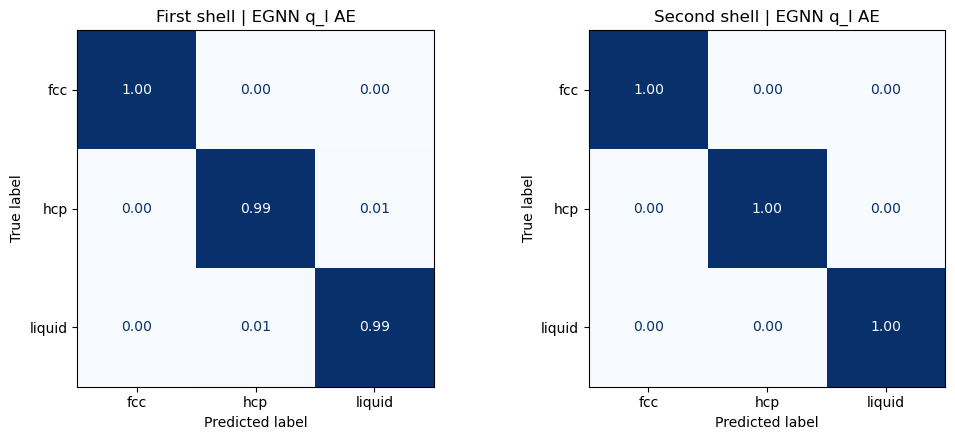

In [24]:
def plot_egnn_ql_latents(artifacts, method=EGNN_VIS_METHOD):
    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(12, 4.8), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        art = artifacts[shell_name]
        Z_plot, y_plot, projection_label = project_egnn_latent_for_plot(art["Z"], art["y"], method=method)
        for phase in PHASES:
            lab = LABEL_MAP[phase]
            mask = y_plot == lab
            ax.scatter(
                Z_plot[mask, 0],
                Z_plot[mask, 1],
                s=SCATTER_S,
                alpha=SCATTER_ALPHA,
                color=LABEL_COLORS[lab],
                label=phase,
            )
        score = art["scores"]["balanced_accuracy"]
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN q_l AE | bal. acc={score:.3f}")
        ax.set_xlabel(projection_label + " 1")
        ax.set_ylabel(projection_label + " 2")
        ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(PHASES),
        bbox_to_anchor=(0.5, 1.05),
        markerscale=LEGEND_MARKERSCALE,
        fontsize=LEGEND_FONTSIZE,
    )
    plt.tight_layout()
    plt.show()


def plot_egnn_ql_confusions(artifacts, normalize="true"):
    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(10.5, 4.5), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        scores = artifacts[shell_name]["scores"]
        names = [LABEL_NAMES[i] for i in scores["labels"]]
        cm = confusion_matrix(
            scores["y_test"],
            scores["y_pred"],
            labels=scores["labels"],
            normalize=normalize,
        )
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN q_l AE")
        ax.grid(False)
    plt.tight_layout()
    plt.show()

if not SKIP_EGNN_QL:
    plot_egnn_ql_latents(egnn_ql_artifacts, method=EGNN_VIS_METHOD)
    if globals().get("UMAP_AVAILABLE", False):
        plot_egnn_ql_latents(egnn_ql_artifacts, method="umap")
    plot_egnn_ql_confusions(egnn_ql_artifacts, normalize="true")


## 18) q_l-target EGNN delta and training curves

,delta_latent_accuracy,delta_latent_balanced_accuracy,delta_latent_macro_f1,delta_final_val_loss
0,0.0059,0.0059,0.006,-0.0004


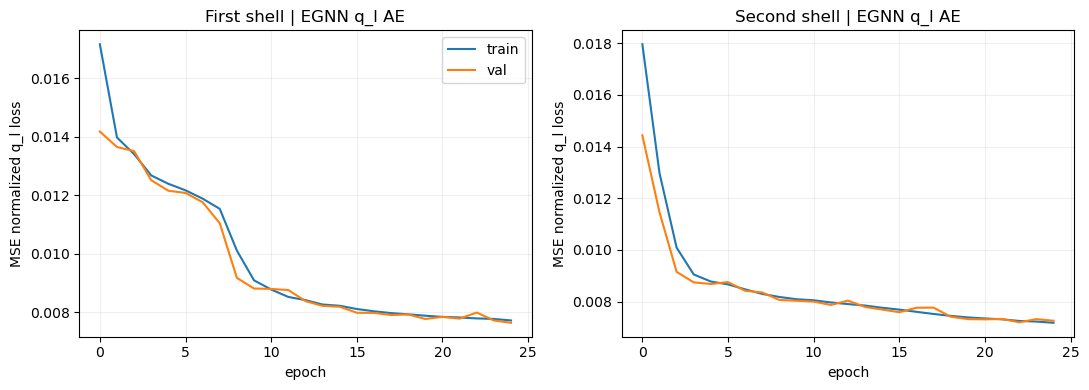

In [25]:
if not SKIP_EGNN_QL:
    egnn_ql_metric_cols = ["latent_accuracy", "latent_balanced_accuracy", "latent_macro_f1", "final_val_loss"]
    egnn_ql_wide = egnn_ql_scores_df.set_index("shell")[egnn_ql_metric_cols]
    egnn_ql_delta = {
        f"delta_{metric}": egnn_ql_wide.loc["second_shell", metric] - egnn_ql_wide.loc["first_shell", metric]
        for metric in egnn_ql_metric_cols
    }
    display(pd.DataFrame([egnn_ql_delta]).round(4))

    fig, axes = plt.subplots(1, len(SHELL_ORDER), figsize=(11, 4), squeeze=False)
    for ax, shell_name in zip(axes[0], SHELL_ORDER):
        hist = egnn_ql_artifacts[shell_name]["history"]
        ax.plot(hist["loss"], label="train")
        ax.plot(hist["val_loss"], label="val")
        ax.set_title(f"{SHELL_LABELS[shell_name]} | EGNN q_l AE")
        ax.set_xlabel("epoch")
        ax.set_ylabel("MSE normalized q_l loss")
        ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()


## 19) Matched \(q_l\), \(q_{lm}\), and \(Y_{lm}\) reconstruction goals

### Feasibility and comparison protocol

Raw \(q_{lm}\) and \(Y_{lm}\) coefficients depend on the laboratory-frame orientation, while the pooled EGNN latent above is invariant to rotations and reflections. A deterministic decoder therefore cannot reconstruct raw lab-frame coefficients from this latent: rotated copies have the same latent but different targets.

To make the comparison well-defined, each neighbourhood is expressed in a deterministic local orthogonal frame before evaluating real spherical harmonics. The frame uses the shortest bond as its first axis, the most orthogonal remaining bond as its second axis, and the bond with the largest residual outside that plane as its third axis. This construction is invariant under any global orthogonal transformation (rotation or reflection). Neighbours are sorted by radius before the bond-wise \(Y_{lm}\) target is flattened.

The three matched targets form a strict information hierarchy using the same bonds and harmonic degrees:

\[
Y_{lm}(\hat{\mathbf r}_{ij})
\;\longrightarrow\;
q_{lm} = \frac{1}{N_b}\sum_j Y_{lm}(\hat{\mathbf r}_{ij})
\;\longrightarrow\;
q_l = \sqrt{\frac{4\pi}{2l+1}\sum_m q_{lm}^2}.
\]

The default uses the standard crystallinity channels \(l=4,6\). This keeps the bond-wise target tractable: 264 real values for 12 target bonds rather than 10,560 real/imaginary values for all \(l=1,\ldots,20\). Increase `ANGULAR_L_VALUES` only with a correspondingly smaller sample budget.

`ANGULAR_MATCH_STORED_QL_NEIGHBOURS=True` follows the existing notebook protocol: the second-shell EGNN receives 18 neighbours, but all angular targets use the first 12 bonds because the NPZ metadata says `descriptor_nn=12` and its stored `q_l`/`q_l_no_average` descriptors are identical across the first- and second-shell files. Set it to `False` to define genuinely 18-bond second-shell angular targets instead.

The primary result is the linear-probe accuracy of each EGNN latent. A second table probes the targets directly; it is a useful upper-bound diagnostic for how linearly accessible the phase information is before compression, not an autoencoder score.

In [26]:
from scipy.special import sph_harm

ANGULAR_L_VALUES = (4, 6)
ANGULAR_GOALS = ("ql", "qlm", "ylm")
ANGULAR_GOAL_LABELS = {
    "ql": r"$q_l$",
    "qlm": r"$q_{lm}$",
    "ylm": r"$Y_{lm}$",
}
ANGULAR_MATCH_STORED_QL_NEIGHBOURS = True
EGNN_ANGULAR_MAX_SAMPLES_PER_PHASE = min(6000, EGNN_MAX_SAMPLES_PER_PHASE)
EGNN_ANGULAR_EPOCHS = EGNN_EPOCHS
ANGULAR_LATENT_ROWS_PER_PHASE = 3


def canonicalize_bond_vectors(vec, eps=1e-8):
    """Return radius-sorted bonds in a deterministic O(3)-invariant local frame."""
    vec = np.asarray(vec, dtype=np.float32)
    radii = np.linalg.norm(vec, axis=-1)
    order = np.argsort(radii, axis=1, kind="stable")
    vec = np.take_along_axis(vec, order[..., None], axis=1)
    unit = vec / np.maximum(np.linalg.norm(vec, axis=-1, keepdims=True), eps)

    e1 = unit[:, 0]

    proj1 = np.einsum("bnd,bd->bn", unit, e1)
    residual2 = unit - proj1[..., None] * e1[:, None]
    residual2_norm = np.linalg.norm(residual2, axis=-1)
    residual2_norm[:, 0] = -np.inf
    idx2 = np.argmax(residual2_norm, axis=1)
    e2_raw = residual2[np.arange(len(vec)), idx2]
    e2_norm = np.linalg.norm(e2_raw, axis=-1, keepdims=True)
    if np.any(e2_norm[:, 0] < eps):
        raise ValueError("Cannot construct angular frame: all target bonds are collinear.")
    e2 = e2_raw / e2_norm

    proj2 = np.einsum("bnd,bd->bn", unit, e2)
    residual3 = unit - proj1[..., None] * e1[:, None] - proj2[..., None] * e2[:, None]
    residual3_norm = np.linalg.norm(residual3, axis=-1)
    residual3_norm[:, 0] = -np.inf
    residual3_norm[np.arange(len(vec)), idx2] = -np.inf
    idx3 = np.argmax(residual3_norm, axis=1)
    e3_raw = residual3[np.arange(len(vec)), idx3]
    e3_norm = np.linalg.norm(e3_raw, axis=-1, keepdims=True)
    if np.any(e3_norm[:, 0] < eps):
        raise ValueError("Cannot construct angular frame: all target bonds are coplanar.")
    e3 = e3_raw / e3_norm

    local = np.stack(
        [
            np.einsum("bnd,bd->bn", vec, e1),
            np.einsum("bnd,bd->bn", vec, e2),
            np.einsum("bnd,bd->bn", vec, e3),
        ],
        axis=-1,
    ).astype(np.float32)
    frame_quality = {
        "second_axis_residual_min": float(e2_norm.min()),
        "third_axis_residual_min": float(e3_norm.min()),
    }
    return local, frame_quality


def real_spherical_harmonics(unit_vectors, l_values=ANGULAR_L_VALUES):
    """Real orthonormal spherical-harmonic basis ordered by l, then m=-l,...,+l."""
    unit_vectors = np.asarray(unit_vectors)
    theta = np.arccos(np.clip(unit_vectors[..., 2], -1.0, 1.0))
    phi = np.mod(np.arctan2(unit_vectors[..., 1], unit_vectors[..., 0]), 2.0 * np.pi)
    channels = []
    channel_slices = {}
    start = 0
    for ell in l_values:
        for m in range(-ell, ell + 1):
            if m < 0:
                value = np.sqrt(2.0) * ((-1.0) ** m) * sph_harm(-m, ell, phi, theta).imag
            elif m == 0:
                value = sph_harm(0, ell, phi, theta).real
            else:
                value = np.sqrt(2.0) * ((-1.0) ** m) * sph_harm(m, ell, phi, theta).real
            channels.append(value)
        channel_slices[ell] = slice(start, start + 2 * ell + 1)
        start += 2 * ell + 1
    return np.stack(channels, axis=-1).astype(np.float32), channel_slices


def angular_reconstruction_targets(vec, l_values=ANGULAR_L_VALUES):
    """Compute matched local q_l, canonical q_lm, and canonical bond-wise Y_lm."""
    local_vec, frame_quality = canonicalize_bond_vectors(vec)
    unit = local_vec / np.maximum(np.linalg.norm(local_vec, axis=-1, keepdims=True), 1e-8)
    ylm, channel_slices = real_spherical_harmonics(unit, l_values=l_values)
    qlm = ylm.mean(axis=1)
    ql = np.stack(
        [
            np.sqrt(
                4.0 * np.pi / (2 * ell + 1)
                * np.sum(qlm[:, channel_slice] ** 2, axis=1)
            )
            for ell, channel_slice in channel_slices.items()
        ],
        axis=1,
    ).astype(np.float32)
    return {
        "ql": ql,
        "qlm": qlm.astype(np.float32),
        "ylm": ylm.reshape(len(ylm), -1).astype(np.float32),
    }, frame_quality


def target_neighbour_count(data):
    if ANGULAR_MATCH_STORED_QL_NEIGHBOURS:
        descriptor_nn = data["meta"].get("descriptor_nn")
        if descriptor_nn is not None:
            return int(descriptor_nn)
    return int(data["vec_dist"].shape[1])


def orthogonal_matrix(seed=SEED, reflection=False):
    rng = np.random.default_rng(seed)
    q, _ = np.linalg.qr(rng.normal(size=(3, 3)))
    desired_det = -1.0 if reflection else 1.0
    if np.linalg.det(q) * desired_det < 0:
        q[:, 0] *= -1.0
    return q.astype(np.float32)


def angular_target_invariance_report(shell_data, n_samples=32):
    rows = []
    transforms = {
        "rotation": orthogonal_matrix(SEED, reflection=False),
        "reflection": orthogonal_matrix(SEED + 1, reflection=True),
    }
    for shell_name in SHELL_ORDER:
        data = shell_data[shell_name][PHASES[0]]
        target_nn = target_neighbour_count(data)
        vec = data["vec_dist"][:n_samples, :target_nn]
        reference, _ = angular_reconstruction_targets(vec)
        for transform_name, matrix in transforms.items():
            transformed, _ = angular_reconstruction_targets(vec @ matrix)
            rows.append({
                "shell": shell_name,
                "transform": transform_name,
                **{
                    f"{goal}_max_abs_error": float(
                        np.max(np.abs(reference[goal] - transformed[goal]))
                    )
                    for goal in ANGULAR_GOALS
                },
            })
    return pd.DataFrame(rows)


display(angular_target_invariance_report(shell_data).round(7))

/tmp/ipykernel_737/3750326583.py:75: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = np.sqrt(2.0) * ((-1.0) ** m) * sph_harm(-m, ell, phi, theta).imag
/tmp/ipykernel_737/3750326583.py:77: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = sph_harm(0, ell, phi, theta).real
/tmp/ipykernel_737/3750326583.py:79: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = np.sqrt(2.0) * ((-1.0) ** m) * sph_harm(m, ell, phi, theta).real


,shell,transform,ql_max_abs_error,qlm_max_abs_error,ylm_max_abs_error
0,first_shell,rotation,1.000000e-07,2.000000e-07,0.000002
1,first_shell,reflection,1.000000e-07,2.000000e-07,0.000002
2,second_shell,rotation,1.000000e-07,2.000000e-07,0.000002
3,second_shell,reflection,1.000000e-07,2.000000e-07,0.000002


In [27]:
class EGNNAngularAE(nn.Module):
    def __init__(
        self,
        target_dim,
        latent_dim=EGNN_LATENT_DIM,
        feat_dim=EGNN_FEAT_DIM,
        n_layers=EGNN_N_LAYERS,
    ):
        super().__init__()
        self.encoder = EGNNEncoder(
            n_layers=n_layers,
            feat_dim=feat_dim,
            latent_dim=latent_dim,
        )
        self.decoder = InvariantSignatureDecoder(
            latent_dim,
            target_dim,
            hidden_dim=feat_dim,
        )

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def forward(self, x, edge_index):
        z = self.encode(x, edge_index)
        return self.decoder(z), z


def make_egnn_angular_data(
    data_by_phase,
    max_samples_per_phase=EGNN_ANGULAR_MAX_SAMPLES_PER_PHASE,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    xs, ys = [], []
    targets_by_goal = {goal: [] for goal in ANGULAR_GOALS}
    validation_rows = []
    target_nns = set()

    for phase in PHASES:
        data = data_by_phase[phase]
        n = data["vec_dist"].shape[0]
        if max_samples_per_phase is not None and n > max_samples_per_phase:
            idx = rng.choice(n, size=max_samples_per_phase, replace=False)
        else:
            idx = np.arange(n)

        x_phase = data["vec_dist"][idx].astype(np.float32)
        target_nn = target_neighbour_count(data)
        target_nns.add(target_nn)
        phase_targets, frame_quality = angular_reconstruction_targets(
            x_phase[:, :target_nn]
        )
        for goal in ANGULAR_GOALS:
            targets_by_goal[goal].append(phase_targets[goal])

        validation_row = {
            "phase": phase,
            "target_neighbours": target_nn,
            **frame_quality,
        }
        if "ql_no_average" in data:
            reference = data["ql_no_average"][idx][:, [ell - 1 for ell in ANGULAR_L_VALUES]]
            abs_error = np.abs(phase_targets["ql"] - reference)
            validation_row.update({
                "q_l_reference_mae": float(abs_error.mean()),
                "q_l_reference_p95": float(np.quantile(abs_error, 0.95)),
                "q_l_reference_corr": float(
                    np.corrcoef(phase_targets["ql"].ravel(), reference.ravel())[0, 1]
                ),
            })
        validation_rows.append(validation_row)
        xs.append(x_phase)
        ys.append(np.full(len(idx), LABEL_MAP[phase], dtype=int))

    X = np.concatenate(xs, axis=0)
    y = np.concatenate(ys, axis=0)
    X = with_central_point(X)
    X_scaled, coord_scale = scale_coords_by_median_radius(X)

    scaled_targets = {}
    target_scalers = {}
    for goal, phase_targets in targets_by_goal.items():
        target = np.concatenate(phase_targets, axis=0)
        scaler = MinMaxScaler()
        scaled_targets[goal] = scaler.fit_transform(target).astype(np.float32)
        target_scalers[goal] = scaler

    return {
        "X": X_scaled,
        "y": y,
        "targets": scaled_targets,
        "target_scalers": target_scalers,
        "coord_scale": coord_scale,
        "target_nns": sorted(target_nns),
        "validation": pd.DataFrame(validation_rows),
    }


def train_egnn_angular_ae(
    X,
    y,
    target,
    epochs=EGNN_ANGULAR_EPOCHS,
    batch_size=EGNN_BATCH_SIZE,
    seed=SEED,
):
    torch.manual_seed(seed)
    X_train, X_val, target_train, target_val = train_test_split(
        X,
        target,
        test_size=0.2,
        random_state=seed,
        stratify=y,
        shuffle=True,
    )
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(target_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(target_val)),
        batch_size=batch_size,
        shuffle=False,
    )

    edge_index = make_fully_connected_edges(X.shape[1]).to(DEVICE)
    model = EGNNAngularAE(target_dim=target.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=EGNN_LR,
        weight_decay=EGNN_WEIGHT_DECAY,
    )
    history = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, target_b in train_loader:
            xb = xb.to(DEVICE)
            target_b = target_b.to(DEVICE)
            prediction, _ = model(xb, edge_index)
            loss = F.mse_loss(prediction, target_b)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), EGNN_GRAD_CLIP)
            optimizer.step()
            total += loss.item() * xb.size(0)
        history["loss"].append(total / len(train_loader.dataset))

        model.eval()
        total = 0.0
        with torch.no_grad():
            for xb, target_b in val_loader:
                xb = xb.to(DEVICE)
                target_b = target_b.to(DEVICE)
                prediction, _ = model(xb, edge_index)
                total += F.mse_loss(prediction, target_b).item() * xb.size(0)
        history["val_loss"].append(total / len(val_loader.dataset))

        if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(
                f"epoch {epoch + 1:03d} | "
                f"train={history['loss'][-1]:.5f} | "
                f"val={history['val_loss'][-1]:.5f}"
            )

    model.eval()
    latent_batches = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb = torch.tensor(
                X[start:start + batch_size],
                dtype=torch.float32,
                device=DEVICE,
            )
            latent_batches.append(model.encode(xb, edge_index).cpu().numpy())
    Z = np.concatenate(latent_batches, axis=0)
    return model, history, Z, edge_index


def run_egnn_angular_suite(shell_data):
    rows = []
    artifacts = {}
    validation_tables = []

    for shell_name in SHELL_ORDER:
        prepared = make_egnn_angular_data(shell_data[shell_name])
        validation = prepared["validation"].copy()
        validation.insert(0, "shell", shell_name)
        validation_tables.append(validation)

        for goal in ANGULAR_GOALS:
            print("=" * 72)
            print(
                f"EGNN {ANGULAR_GOAL_LABELS[goal]} AE | "
                f"{SHELL_LABELS[shell_name]}"
            )
            print("=" * 72)
            target = prepared["targets"][goal]
            model, history, Z, edge_index = train_egnn_angular_ae(
                prepared["X"],
                prepared["y"],
                target,
            )
            latent_scores = score_latent_classifier(Z, prepared["y"])
            target_scores = score_latent_classifier(target, prepared["y"])
            diagnostics = latent_diagnostics(Z)

            rows.append({
                "shell": shell_name,
                "shell_label": SHELL_LABELS[shell_name],
                "target": goal,
                "target_label": ANGULAR_GOAL_LABELS[goal],
                "l_values": str(ANGULAR_L_VALUES),
                "n_samples": len(prepared["y"]),
                "n_points": prepared["X"].shape[1],
                "target_neighbours": str(prepared["target_nns"]),
                "target_dim": target.shape[1],
                "latent_dim": Z.shape[1],
                "coord_scale": prepared["coord_scale"],
                "final_val_loss": history["val_loss"][-1],
                "latent_accuracy": latent_scores["accuracy"],
                "latent_balanced_accuracy": latent_scores["balanced_accuracy"],
                "latent_macro_f1": latent_scores["macro_f1"],
                "target_accuracy": target_scores["accuracy"],
                "target_balanced_accuracy": target_scores["balanced_accuracy"],
                **diagnostics,
            })
            artifacts[(shell_name, goal)] = {
                "X": prepared["X"],
                "y": prepared["y"],
                "target": target,
                "target_scaler": prepared["target_scalers"][goal],
                "model": model,
                "history": history,
                "Z": Z,
                "scores": latent_scores,
                "target_scores": target_scores,
                "edge_index": edge_index,
                "coord_scale": prepared["coord_scale"],
            }

    return (
        pd.DataFrame(rows),
        artifacts,
        pd.concat(validation_tables, ignore_index=True),
    )

In [28]:
if not SKIP_EGNN_ANGULAR:
    (
        egnn_angular_scores_df,
        egnn_angular_artifacts,
        angular_target_validation_df,
    ) = run_egnn_angular_suite(shell_data)

    print("Target construction diagnostics")
    display(angular_target_validation_df.round(5))
    print("Full matched angular reconstruction results")
    display(
        egnn_angular_scores_df.sort_values(["target", "shell"]).round(4)
    )

/tmp/ipykernel_737/3750326583.py:75: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = np.sqrt(2.0) * ((-1.0) ** m) * sph_harm(-m, ell, phi, theta).imag
/tmp/ipykernel_737/3750326583.py:77: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = sph_harm(0, ell, phi, theta).real
/tmp/ipykernel_737/3750326583.py:79: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = np.sqrt(2.0) * ((-1.0) ** m) * sph_harm(m, ell, phi, theta).real


EGNN $q_l$ AE | First shell
epoch 001 | train=0.01822 | val=0.01277
epoch 005 | train=0.01191 | val=0.01053
epoch 010 | train=0.00844 | val=0.00845
epoch 015 | train=0.00824 | val=0.00854
epoch 020 | train=0.00823 | val=0.00843
epoch 025 | train=0.00825 | val=0.00847
EGNN $q_{lm}$ AE | First shell
epoch 001 | train=0.01765 | val=0.01634
epoch 005 | train=0.01529 | val=0.01526
epoch 010 | train=0.01522 | val=0.01513
epoch 015 | train=0.01522 | val=0.01504
epoch 020 | train=0.01521 | val=0.01501
epoch 025 | train=0.01517 | val=0.01499
EGNN $Y_{lm}$ AE | First shell
epoch 001 | train=0.05282 | val=0.04117
epoch 005 | train=0.04071 | val=0.04066
epoch 010 | train=0.04058 | val=0.04054
epoch 015 | train=0.04054 | val=0.04049
epoch 020 | train=0.04052 | val=0.04048
epoch 025 | train=0.04051 | val=0.04050


/tmp/ipykernel_737/3750326583.py:75: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = np.sqrt(2.0) * ((-1.0) ** m) * sph_harm(-m, ell, phi, theta).imag
/tmp/ipykernel_737/3750326583.py:77: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = sph_harm(0, ell, phi, theta).real
/tmp/ipykernel_737/3750326583.py:79: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  value = np.sqrt(2.0) * ((-1.0) ** m) * sph_harm(m, ell, phi, theta).real


EGNN $q_l$ AE | Second shell
epoch 001 | train=0.01819 | val=0.01278
epoch 005 | train=0.01252 | val=0.01284
epoch 010 | train=0.00862 | val=0.00854
epoch 015 | train=0.00793 | val=0.00828
epoch 020 | train=0.00762 | val=0.00802
epoch 025 | train=0.00727 | val=0.00805
EGNN $q_{lm}$ AE | Second shell
epoch 001 | train=0.01765 | val=0.01638
epoch 005 | train=0.01536 | val=0.01516
epoch 010 | train=0.01528 | val=0.01510
epoch 015 | train=0.01518 | val=0.01503
epoch 020 | train=0.01514 | val=0.01500
epoch 025 | train=0.01511 | val=0.01495
EGNN $Y_{lm}$ AE | Second shell
epoch 001 | train=0.05279 | val=0.04117
epoch 005 | train=0.04087 | val=0.04081
epoch 010 | train=0.04065 | val=0.04058
epoch 015 | train=0.04054 | val=0.04051
epoch 020 | train=0.04052 | val=0.04051
epoch 025 | train=0.04050 | val=0.04050
Target construction diagnostics


,shell,phase,target_neighbours,second_axis_residual_min,third_axis_residual_min,q_l_reference_mae,q_l_reference_p95,q_l_reference_corr
0,first_shell,fcc,12,0.88191,0.69177,0.00206,0.01469,0.99849
1,first_shell,hcp,12,0.90790,0.59865,0.00556,0.04931,0.99201
2,first_shell,liquid,12,0.92538,0.58329,0.00548,0.04394,0.98678
3,second_shell,fcc,12,0.88191,0.69177,0.00206,0.01469,0.99849
4,second_shell,hcp,12,0.90790,0.59865,0.00556,0.04931,0.99201
5,second_shell,liquid,12,0.92538,0.58329,0.00548,0.04394,0.98678


Full matched angular reconstruction results


,shell,shell_label,target,target_label,l_values,n_samples,n_points,target_neighbours,target_dim,latent_dim,coord_scale,final_val_loss,latent_accuracy,latent_balanced_accuracy,latent_macro_f1,target_accuracy,target_balanced_accuracy,latent_std_mean,latent_std_min,latent_abs_mean
0,first_shell,First shell,ql,$q_l$,"(4, 6)",18000,13,[12],2,4,1.0538,0.0085,0.6069,0.6069,0.5838,0.8419,0.8419,0.8069,0.3806,1.5131
3,second_shell,Second shell,ql,$q_l$,"(4, 6)",18000,19,[12],2,4,1.1165,0.0080,0.6519,0.6519,0.6475,0.8419,0.8419,0.7628,0.4786,0.9423
1,first_shell,First shell,qlm,$q_{lm}$,"(4, 6)",18000,13,[12],22,4,1.0538,0.0150,0.6175,0.6175,0.6042,0.8992,0.8992,0.7700,0.2899,0.6791
4,second_shell,Second shell,qlm,$q_{lm}$,"(4, 6)",18000,19,[12],22,4,1.1165,0.0150,0.6392,0.6392,0.6382,0.8992,0.8992,1.0533,0.2720,0.8335
2,first_shell,First shell,ylm,$Y_{lm}$,"(4, 6)",18000,13,[12],264,4,1.0538,0.0405,0.6122,0.6122,0.5973,0.9000,0.9000,0.4936,0.2209,2.8292
5,second_shell,Second shell,ylm,$Y_{lm}$,"(4, 6)",18000,19,[12],264,4,1.1165,0.0405,0.6275,0.6275,0.6243,0.9000,0.9000,0.4529,0.2432,2.5924


## 20) Angular-target latent representations, confusion matrices, and accuracy tables

The scatter panels are 2D projections for visualization only. The printed rows contain samples of the full EGNN latent vectors, and all accuracy/confusion results use the full latent.

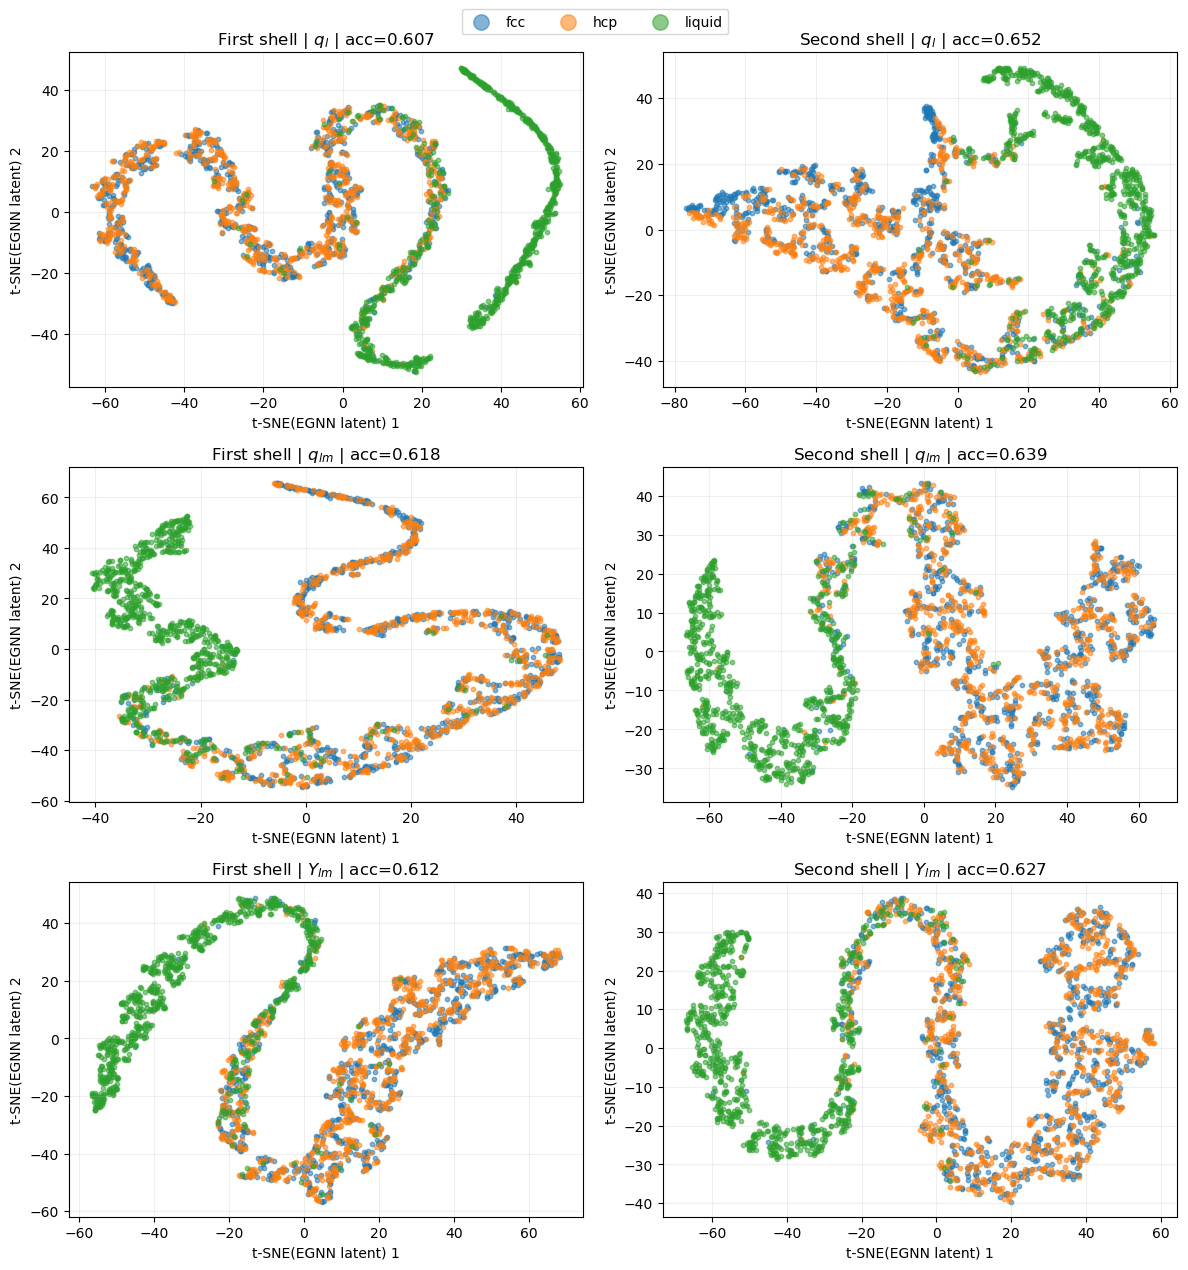

,shell,target,phase,sample_index,z_0,z_1,z_2,z_3
0,First shell,$q_l$,fcc,0,1.68109,1.52461,-3.58185,-1.51469
1,First shell,$q_l$,fcc,1,1.84411,1.63346,-3.99426,-1.66354
2,First shell,$q_l$,fcc,2,1.75168,1.58049,-3.74853,-1.58553
3,First shell,$q_l$,hcp,6000,1.40795,1.34720,-2.92177,-1.29796
4,First shell,$q_l$,hcp,6001,1.65571,1.55616,-3.50785,-1.52371
5,First shell,$q_l$,hcp,6002,1.58544,1.48046,-3.34642,-1.44534
6,First shell,$q_l$,liquid,12000,0.38769,0.96394,-0.57223,-0.58581
7,First shell,$q_l$,liquid,12001,1.26033,1.40758,-2.49535,-1.24853
8,First shell,$q_l$,liquid,12002,0.02884,0.66920,0.13016,-0.20447
9,Second shell,$q_l$,fcc,0,2.69337,0.51431,-3.92449,0.04836


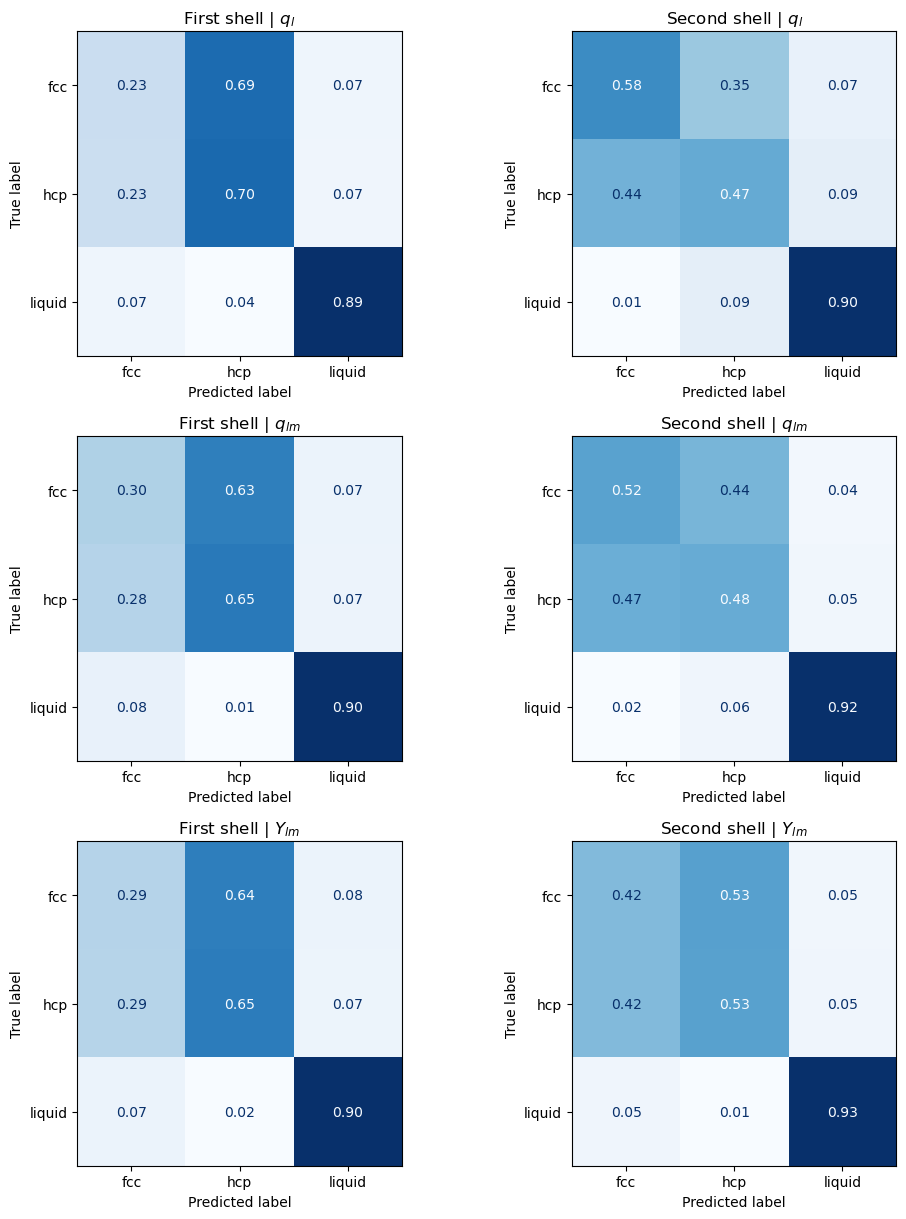

Linear-probe accuracy from the full EGNN latent (primary comparison)


target_label,$Y_{lm}$,$q_l$,$q_{lm}$
input shell,,,
First shell,0.6122,0.6069,0.6175
Second shell,0.6275,0.6519,0.6392


Linear-probe accuracy from each reconstruction target (information diagnostic)


target_label,$Y_{lm}$,$q_l$,$q_{lm}$
target shell,,,
First shell,0.9,0.8419,0.8992
Second shell,0.9,0.8419,0.8992


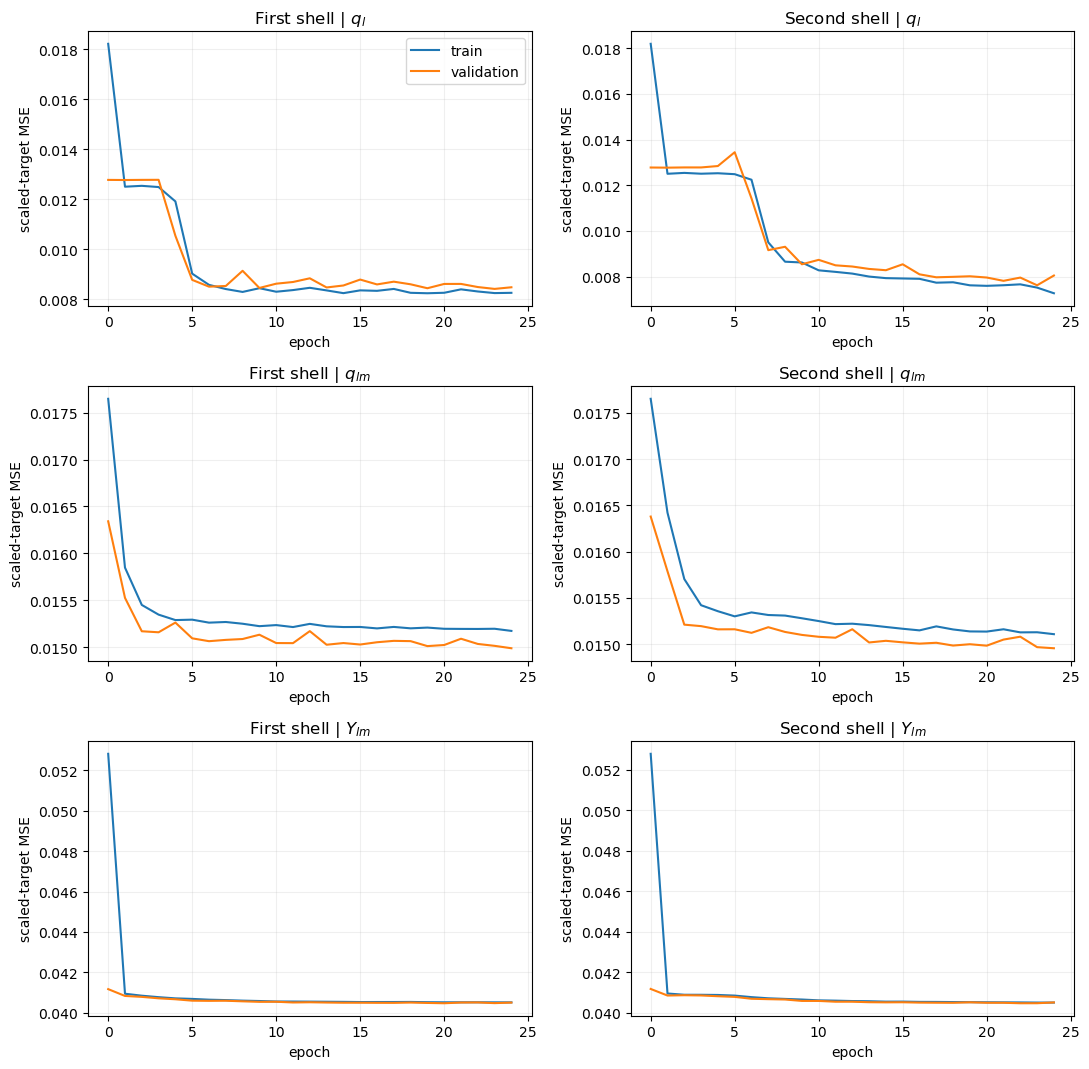

In [29]:
def plot_egnn_angular_latents(artifacts, method=EGNN_VIS_METHOD):
    fig, axes = plt.subplots(
        len(ANGULAR_GOALS),
        len(SHELL_ORDER),
        figsize=(12, 4.2 * len(ANGULAR_GOALS)),
        squeeze=False,
    )
    for row, goal in enumerate(ANGULAR_GOALS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            artifact = artifacts[(shell_name, goal)]
            Z_plot, y_plot, projection_label = project_egnn_latent_for_plot(
                artifact["Z"],
                artifact["y"],
                method=method,
            )
            for phase in PHASES:
                label = LABEL_MAP[phase]
                mask = y_plot == label
                ax.scatter(
                    Z_plot[mask, 0],
                    Z_plot[mask, 1],
                    s=SCATTER_S,
                    alpha=SCATTER_ALPHA,
                    color=LABEL_COLORS[label],
                    label=phase,
                )
            score = artifact["scores"]["accuracy"]
            ax.set_title(
                f"{SHELL_LABELS[shell_name]} | "
                f"{ANGULAR_GOAL_LABELS[goal]} | acc={score:.3f}"
            )
            ax.set_xlabel(projection_label + " 1")
            ax.set_ylabel(projection_label + " 2")
            ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(PHASES),
        bbox_to_anchor=(0.5, 1.01),
        markerscale=LEGEND_MARKERSCALE,
        fontsize=LEGEND_FONTSIZE,
    )
    plt.tight_layout()
    plt.show()


def display_egnn_angular_latent_samples(
    artifacts,
    rows_per_phase=ANGULAR_LATENT_ROWS_PER_PHASE,
):
    rows = []
    for goal in ANGULAR_GOALS:
        for shell_name in SHELL_ORDER:
            artifact = artifacts[(shell_name, goal)]
            for phase in PHASES:
                label = LABEL_MAP[phase]
                indices = np.flatnonzero(artifact["y"] == label)[:rows_per_phase]
                for sample_index in indices:
                    row = {
                        "shell": SHELL_LABELS[shell_name],
                        "target": ANGULAR_GOAL_LABELS[goal],
                        "phase": phase,
                        "sample_index": int(sample_index),
                    }
                    row.update({
                        f"z_{dim}": float(value)
                        for dim, value in enumerate(artifact["Z"][sample_index])
                    })
                    rows.append(row)
    display(pd.DataFrame(rows).round(5))


def plot_egnn_angular_confusions(artifacts, normalize="true"):
    fig, axes = plt.subplots(
        len(ANGULAR_GOALS),
        len(SHELL_ORDER),
        figsize=(10.5, 4.1 * len(ANGULAR_GOALS)),
        squeeze=False,
    )
    for row, goal in enumerate(ANGULAR_GOALS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            scores = artifacts[(shell_name, goal)]["scores"]
            names = [LABEL_NAMES[label] for label in scores["labels"]]
            cm = confusion_matrix(
                scores["y_test"],
                scores["y_pred"],
                labels=scores["labels"],
                normalize=normalize,
            )
            display_cm = ConfusionMatrixDisplay(cm, display_labels=names)
            display_cm.plot(
                ax=ax,
                cmap="Blues",
                values_format=".2f",
                colorbar=False,
            )
            ax.set_title(
                f"{SHELL_LABELS[shell_name]} | "
                f"{ANGULAR_GOAL_LABELS[goal]}"
            )
            ax.grid(False)
    plt.tight_layout()
    plt.show()


def angular_accuracy_tables(scores_df):
    latent_accuracy = scores_df.pivot(
        index="shell_label",
        columns="target_label",
        values="latent_accuracy",
    ).reindex([SHELL_LABELS[name] for name in SHELL_ORDER])
    target_accuracy = scores_df.pivot(
        index="shell_label",
        columns="target_label",
        values="target_accuracy",
    ).reindex([SHELL_LABELS[name] for name in SHELL_ORDER])
    latent_accuracy.index.name = "input shell"
    target_accuracy.index.name = "target shell"
    return latent_accuracy, target_accuracy


def plot_egnn_angular_training_curves(artifacts):
    fig, axes = plt.subplots(
        len(ANGULAR_GOALS),
        len(SHELL_ORDER),
        figsize=(11, 3.6 * len(ANGULAR_GOALS)),
        squeeze=False,
    )
    for row, goal in enumerate(ANGULAR_GOALS):
        for col, shell_name in enumerate(SHELL_ORDER):
            ax = axes[row, col]
            history = artifacts[(shell_name, goal)]["history"]
            ax.plot(history["loss"], label="train")
            ax.plot(history["val_loss"], label="validation")
            ax.set_title(
                f"{SHELL_LABELS[shell_name]} | "
                f"{ANGULAR_GOAL_LABELS[goal]}"
            )
            ax.set_xlabel("epoch")
            ax.set_ylabel("scaled-target MSE")
            ax.grid(alpha=0.2)
    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()


if not SKIP_EGNN_ANGULAR:
    plot_egnn_angular_latents(
        egnn_angular_artifacts,
        method=EGNN_VIS_METHOD,
    )
    display_egnn_angular_latent_samples(egnn_angular_artifacts)
    plot_egnn_angular_confusions(
        egnn_angular_artifacts,
        normalize="true",
    )

    latent_accuracy_table, direct_target_accuracy_table = angular_accuracy_tables(
        egnn_angular_scores_df
    )
    print("Linear-probe accuracy from the full EGNN latent (primary comparison)")
    display(latent_accuracy_table.round(4))
    print("Linear-probe accuracy from each reconstruction target (information diagnostic)")
    display(direct_target_accuracy_table.round(4))

    plot_egnn_angular_training_curves(egnn_angular_artifacts)